# Recipe Site Traffic Prediction

## Data Validation
This data set had 947 rows and 8 columns. But after a validation, they became 895 rows and 8 columns. The description of the changes for each column is the following:
- Recipe: Unique identifier without missing values or duplicates, same as the description. No cleaning is needed.
- Calories: Numeric values, none negative. 52 missing values. The validation showed that these 52 missing values corresponded to the missing values in the other columns. Meaning that the total rows with missing values were 52, which is just 5.5% of the data. The rows were deleted.
- Carbohydrate: Numeric values, none negative. The process applied to the calories column was applied to this column.
- Sugar: Numeric values, none negative. The process applied to the calories column was applied to this column.
- Protein: Numeric values, none negative. The process applied to the calories column was applied to this column.
- Category: 11 categories without missing values. The category 'Chicken Breast' was added to the existing 'Chicken' category as required in the description, making 10 categories.
- Servings: Initially, category without missing values. Deleted the extra information 'as a snack' in the rows that contained it, since the servings are according to the recipe and transformed the data into numeric values.
- High_traffic: A category where the only value was 'High' if the traffic to the site was high when this recipe was shown. Filled the missing values with 'Not High' since this is what the empty values mean.

In [102]:
# Import the modules and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.feature_selection import SelectFromModel

In [103]:
# Turn the file in a dataset and show its main info
df = pd.read_csv('recipe_site_traffic_2212.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [104]:
# Take a look at the head of the data 
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [105]:
# Check more information about the numeric columns 
df.describe()

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [106]:
# Validate the recipe column for uniqueness
unique_recipes = df['recipe'].nunique()
print(unique_recipes)

947


### Fixing the categorical columns

In [107]:
# Validate possible values for category
df['category'].unique()

array(['Pork', 'Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken Breast', 'Lunch/Snacks', 'Chicken', 'Vegetable', 'Meat',
       'Dessert'], dtype=object)

In [108]:
# Replace all Chicken Breast Values with Chicken as required and validate
df['category'] = df['category'].replace('Chicken Breast','Chicken')
df['category'].unique()

array(['Pork', 'Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken', 'Lunch/Snacks', 'Vegetable', 'Meat', 'Dessert'],
      dtype=object)

In [109]:
# Validate possible values for servings
df['servings'].unique()

array(['6', '4', '1', '2', '4 as a snack', '6 as a snack'], dtype=object)

In [110]:
# Delete the extra information for the servings since the servings are according to the recipe and transform the data in numeric
df['servings'] = df['servings'].str.replace('as a snack','')
df['servings'] = df['servings'].astype(int)
df['servings'].unique()

array([6, 4, 1, 2])

In [111]:
# Fill the empty cells in the column 'high_traffic' with 'Not High' since we only know which rows contain the value 'High'
df['high_traffic'] = df['high_traffic'].fillna('Not High')
print(df['high_traffic'].value_counts())

High        574
Not High    373
Name: high_traffic, dtype: int64


In [112]:
# Check the proportions in the categorical columns
print(df['high_traffic'].value_counts(normalize = True))
print(df['servings'].value_counts(normalize = True))
print(df['category'].value_counts(normalize = True))

High        0.606125
Not High    0.393875
Name: high_traffic, dtype: float64
4    0.412883
6    0.209081
2    0.193242
1    0.184794
Name: servings, dtype: float64
Chicken          0.181626
Breakfast        0.111932
Beverages        0.097149
Lunch/Snacks     0.093981
Potato           0.092925
Pork             0.088701
Vegetable        0.087645
Dessert          0.087645
Meat             0.083421
One Dish Meal    0.074974
Name: category, dtype: float64


### Fixing the numerical columns

According to the dataframe's info there are 52 missing values in each of the numerical columns, calories, carbohydrate, sugar and protein. Now we need to check how many rows contain a missing value in any of its columns.

In [113]:
# Checking the total of rows that contains at least one missing value
missing_val = df[['calories', 'carbohydrate', 'sugar', 'protein']].isna()
count_na = missing_val.any(axis=1).sum()
print(count_na)

52


Corroborate that the 52 missing values in the calories, carbohydrate, sugar and protein columns match each other meaning that just 52 rows have missing values and save these rows in another dataframe.

In [114]:
num_columns = ['calories','carbohydrate','sugar','protein']
min_rows = df[df[num_columns].isna().sum(axis=1) >= 2]
print(len(min_rows))

52


In [115]:
# Check the proportions of the categorical columns in the rows with missing values
print(min_rows['high_traffic'].value_counts(normalize = True))
print(min_rows['category'].value_counts(normalize = True))
print(min_rows['servings'].value_counts(normalize = True))

High        0.75
Not High    0.25
Name: high_traffic, dtype: float64
Pork             0.211538
Chicken          0.173077
Lunch/Snacks     0.134615
Dessert          0.115385
Meat             0.096154
Potato           0.096154
Vegetable        0.096154
One Dish Meal    0.076923
Name: category, dtype: float64
4    0.461538
6    0.250000
2    0.173077
1    0.115385
Name: servings, dtype: float64


Deleting the rows with missing values since they only represent 5.5% of the total rows and imputing multiple values for each of these rows would mean adding noise to the dataset.

In [116]:
# Deleting rows with missing values and checking the dataframe information after it
df = df.dropna(subset=num_columns)
print(df.head())
print(df.info())
print(df.describe())

   recipe  calories  carbohydrate  ...       category  servings high_traffic
1       2     35.48         38.56  ...         Potato         4         High
2       3    914.28         42.68  ...      Breakfast         1     Not High
3       4     97.03         30.56  ...      Beverages         4         High
4       5     27.05          1.85  ...      Beverages         4     Not High
5       6    691.15          3.46  ...  One Dish Meal         2         High

[5 rows x 8 columns]
<class 'pandas.core.frame.DataFrame'>
Int64Index: 895 entries, 1 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        895 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      895 non-null    object 
 6   servings      895 non-null    int64  
 7   high_traffic  895 no

## Exploratory Analysis

### Target variable

We need to predict whether a recipe is going to have high traffic on the website or not, so the high_traffic column is going to be our target variable. Here are some visualizations of the proportions and counts of ‘High’ and ‘Not High’ recipes.

We can notice that the recipes with high traffic are 19.6 percentage points higher than those without high traffic.

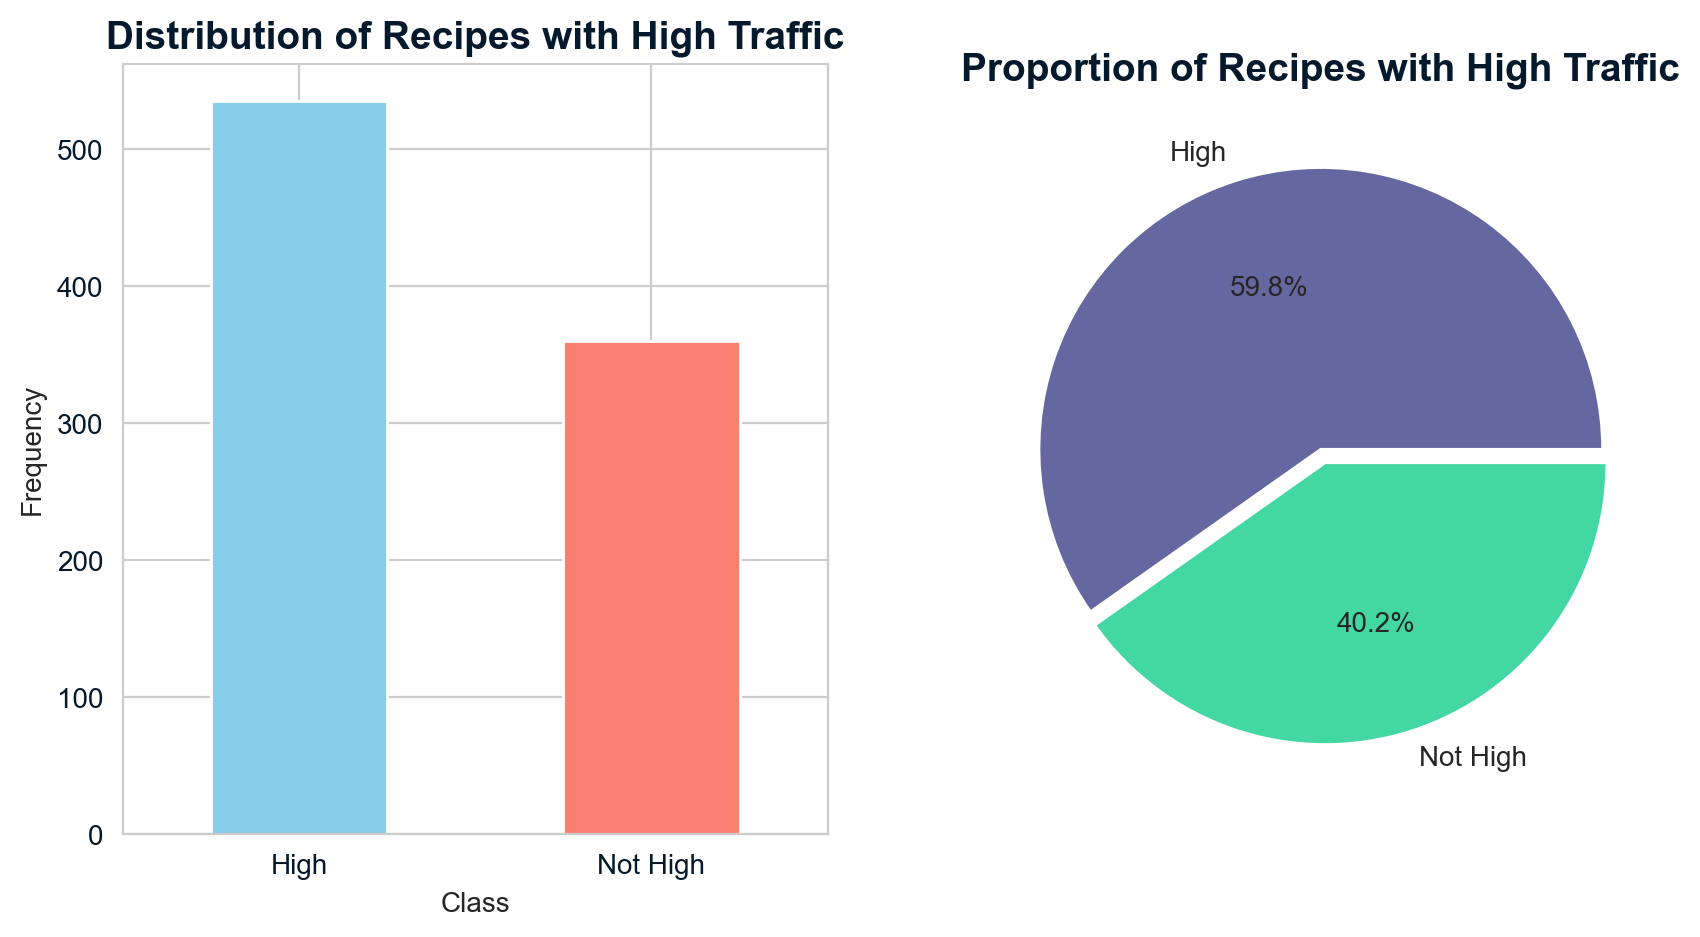

In [117]:
# Target Variable visualization in countplot and piechart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
df['high_traffic'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Distribution of Recipes with High Traffic', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xticklabels(['High', 'Not High'])
df['high_traffic'].value_counts().plot(kind='pie', ax=axes[1], labels=['High', 'Not High'], autopct='%1.1f%%', explode=[0, 0.05], shadow=False)
axes[1].set_title('Proportion of Recipes with High Traffic', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.show()

The graphics calories, carbohydrate, sugar and protein are highly right-skewed, showing a long right tail that can affect the model selected for this classification problem.

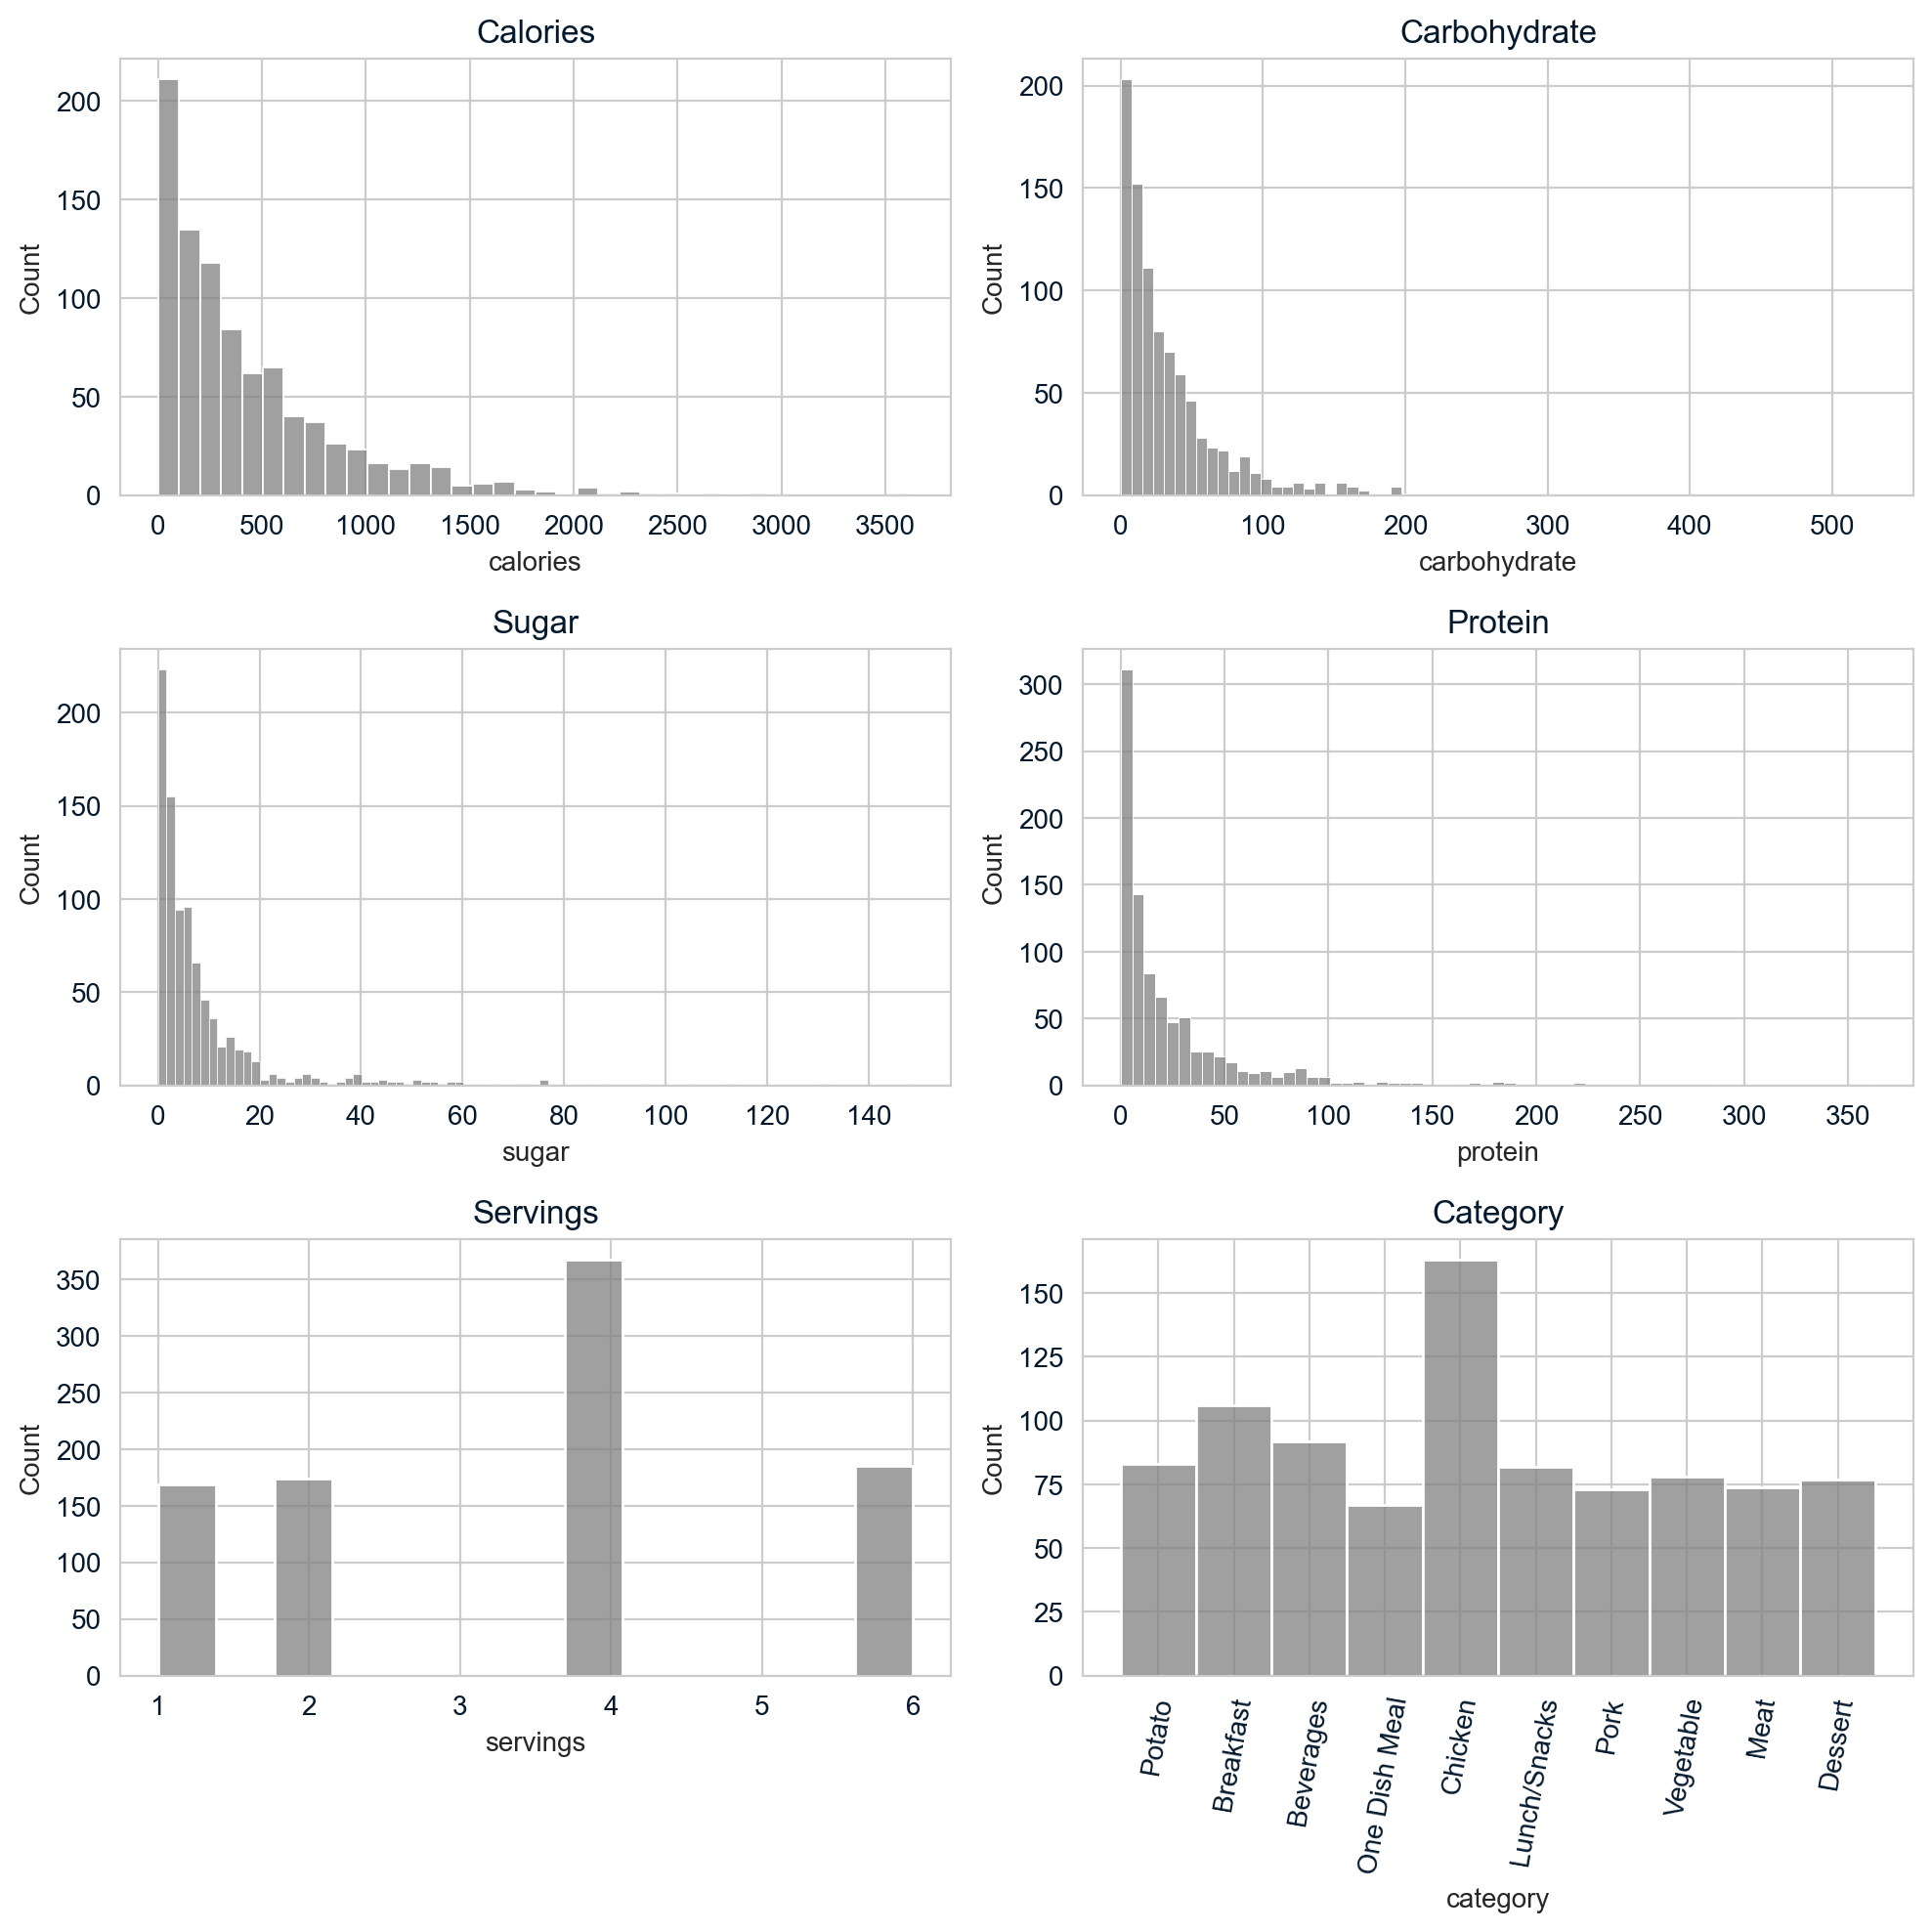

In [118]:
# Histograms of the 'calories', 'carbohydrate', 'sugar', 'protein', 'category' and 'servings' columns.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(df['calories'], color='gray',  ax=axes[0,0])
axes[0,0].set(title='Calories')

sns.histplot(df['carbohydrate'], color='gray', ax=axes[0,1])
axes[0,1].set(title='Carbohydrate')

sns.histplot(df['sugar'], color='gray', ax=axes[1,0])
axes[1,0].set(title='Sugar')

sns.histplot(df['protein'], color='gray', ax=axes[1,1])
axes[1,1].set(title='Protein')

sns.histplot(df['servings'], color='gray',  ax=axes[2,0])
axes[2,0].set(title='Servings')

sns.histplot(df['category'], color='gray',  ax=axes[2,1])
axes[2,1].set(title='Category')
axes[2,1].tick_params(axis='x', rotation=80)

plt.tight_layout()
plt.show()

With the boxplot we can clearly see and confirm the multiple outliers values in the 'calories', 'carbohydrate', 'sugar' and 'protein' columns.

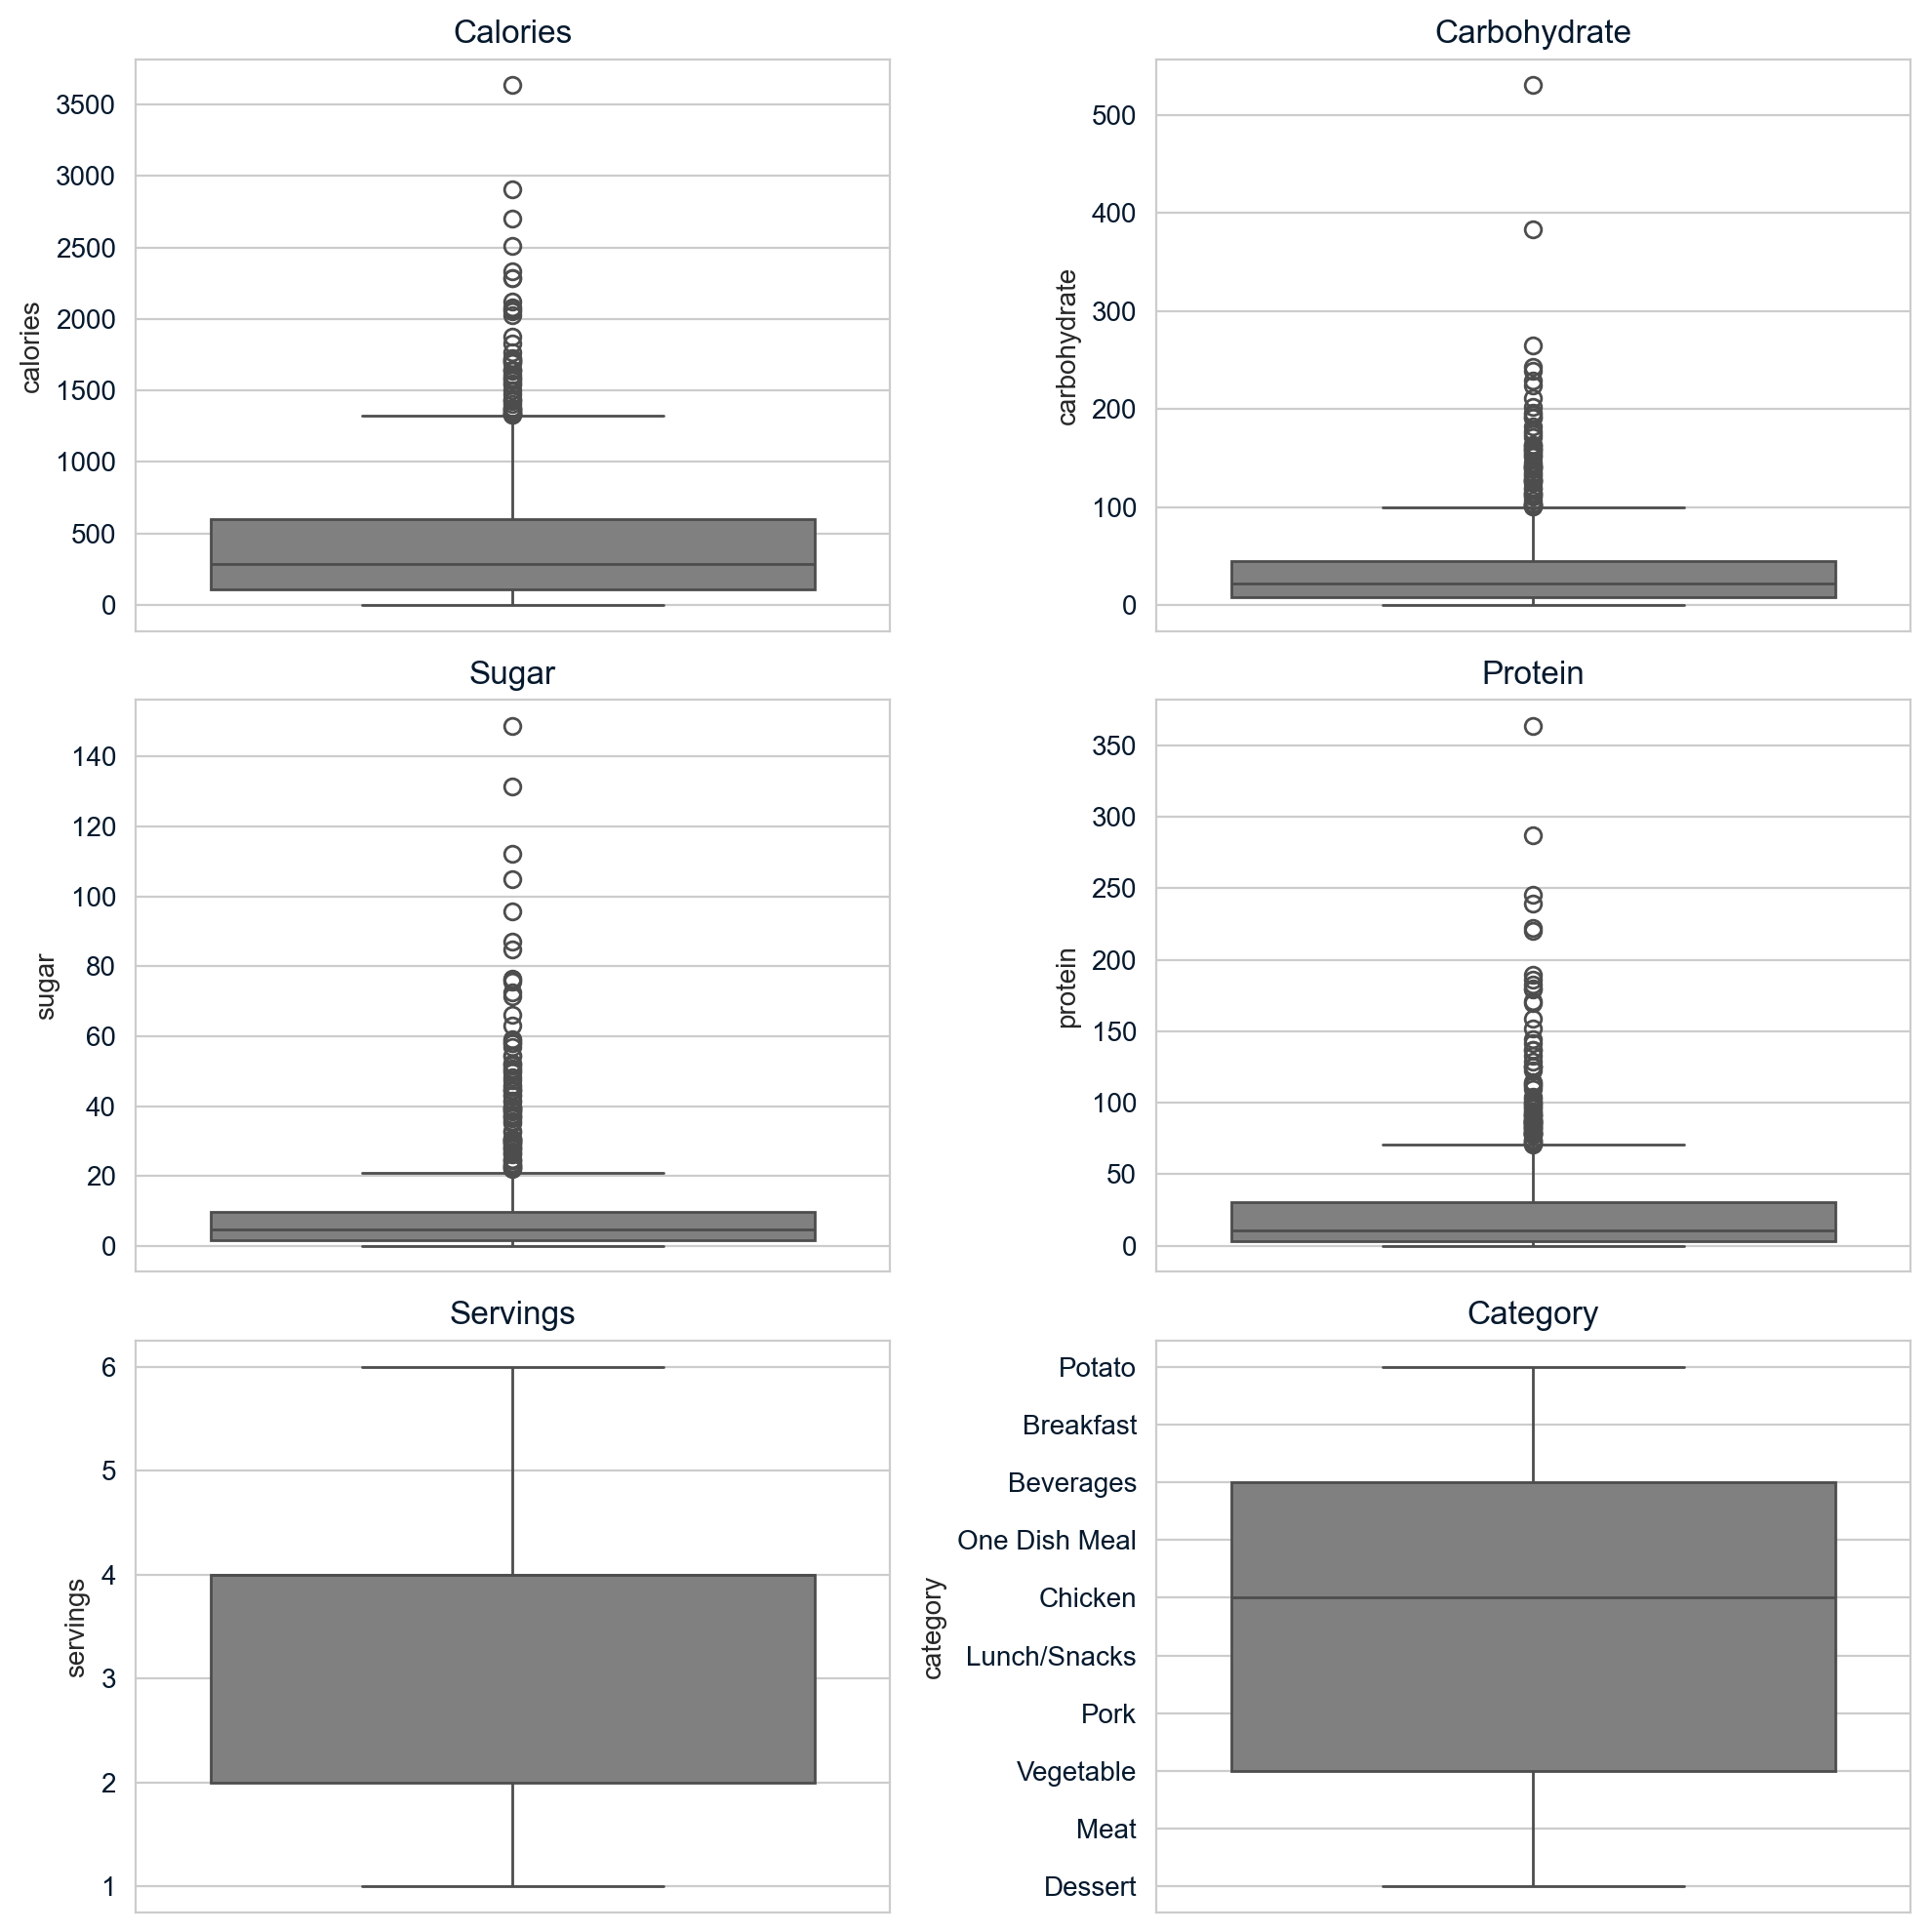

In [119]:
# Box plots of the 'calories', 'carbohydrate', 'sugar', 'protein', 'category' and 'servings' columns.
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.boxplot(df['calories'], color='gray',  ax=axes[0,0])
axes[0,0].set(title='Calories')

sns.boxplot(df['carbohydrate'], color='gray', ax=axes[0,1])
axes[0,1].set(title='Carbohydrate')

sns.boxplot(df['sugar'], color='gray', ax=axes[1,0])
axes[1,0].set(title='Sugar')

sns.boxplot(df['protein'], color='gray', ax=axes[1,1])
axes[1,1].set(title='Protein')

sns.boxplot(df['servings'], color='gray',  ax=axes[2,0])
axes[2,0].set(title='Servings')

sns.boxplot(df['category'], color='gray',  ax=axes[2,1])
axes[2,1].set(title='Category')

plt.tight_layout()
plt.show()

The correlation matrix shows negligible linear relationships between numeric variables. This lack of multicollinearity could be a positive signal, meaning each predictor contributes independently, making their combination potentially powerful for training our model.

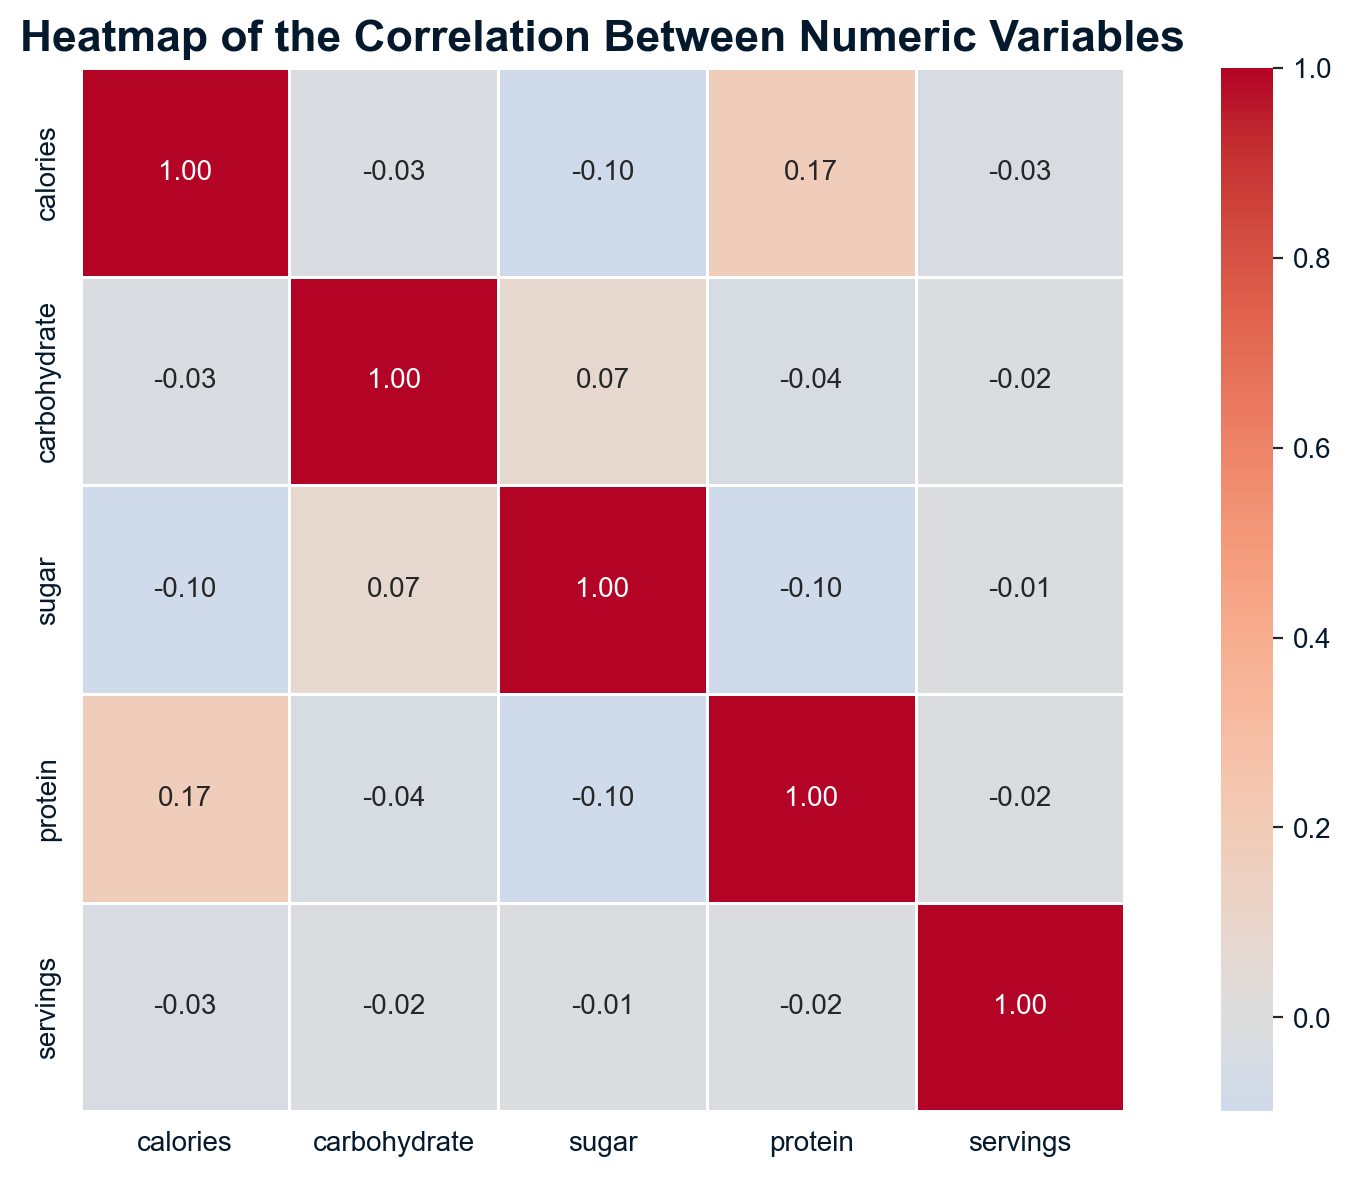

In [120]:
plt.figure(figsize=(10,6))

# Calculate correlation including the target
correlation_matrix = df[['calories', 'carbohydrate', 'sugar', 'protein', 'servings']].corr()

# Heatmap of the correlation
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap of the Correlation Between Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

To see the distribution of the calories, carbohydrate, sugar and protein columns better, we apply the power transformer with the method Yeo-Johnson instead of a Log Scale. Considering that we have values in the column of protein that are 0, this will help us to avoid generating inconsistencies. This shows us a shape closer to the normal distribution of calories, carbohydrate, sugar and protein columns that will be useful for models like Logistic Regression where a distribution without many outliers is helpful. 

It is crucial to note that the applied transformation is for illustrative purposes only; the Yeo-Johnson PowerTransformer will actually be applied to the data after the split into training and test sets.

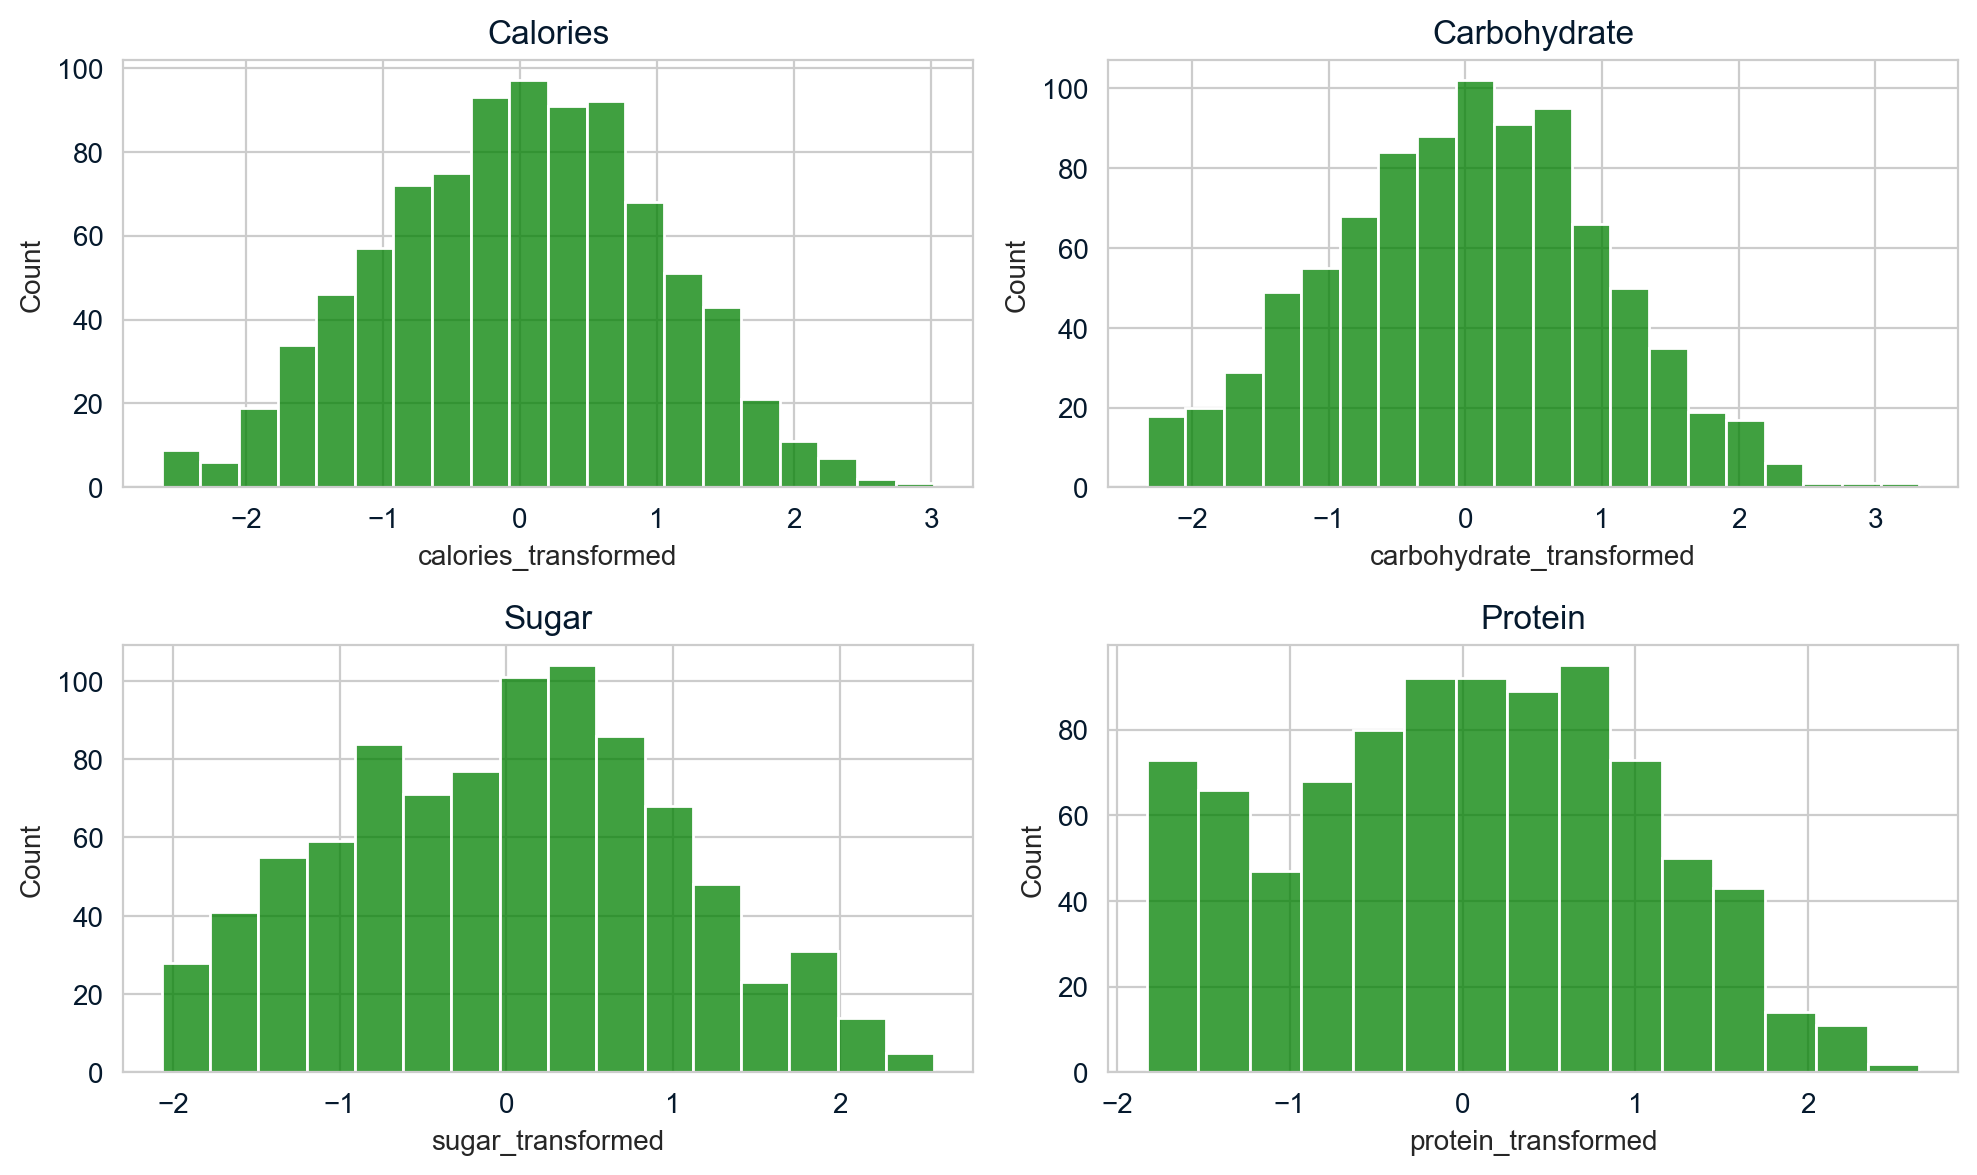

In [121]:
columns_to_transform = ['calories', 'carbohydrate', 'sugar', 'protein']

# Fit and transform the selected columns with PowerTransformer, Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')

df[['calories_transformed', 'carbohydrate_transformed', 'sugar_transformed', 'protein_transformed']] = pt.fit_transform(df[columns_to_transform])

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.histplot(df['calories_transformed'], color='green',  ax=axes[0,0])
axes[0,0].set(title='Calories')

sns.histplot(df['carbohydrate_transformed'], color='green', ax=axes[0,1])
axes[0,1].set(title='Carbohydrate')

sns.histplot(df['sugar_transformed'], color='green', ax=axes[1,0])
axes[1,0].set(title='Sugar')

sns.histplot(df['protein_transformed'], color='green', ax=axes[1,1])
axes[1,1].set(title='Protein')

plt.tight_layout()
plt.show()

After this value transformation, we can compare the difference between the distribution of calories, carbohydrate, sugar and protein for recipes with and without high traffic. We notice that the difference between the boxplots is not too significant in any of the columns.

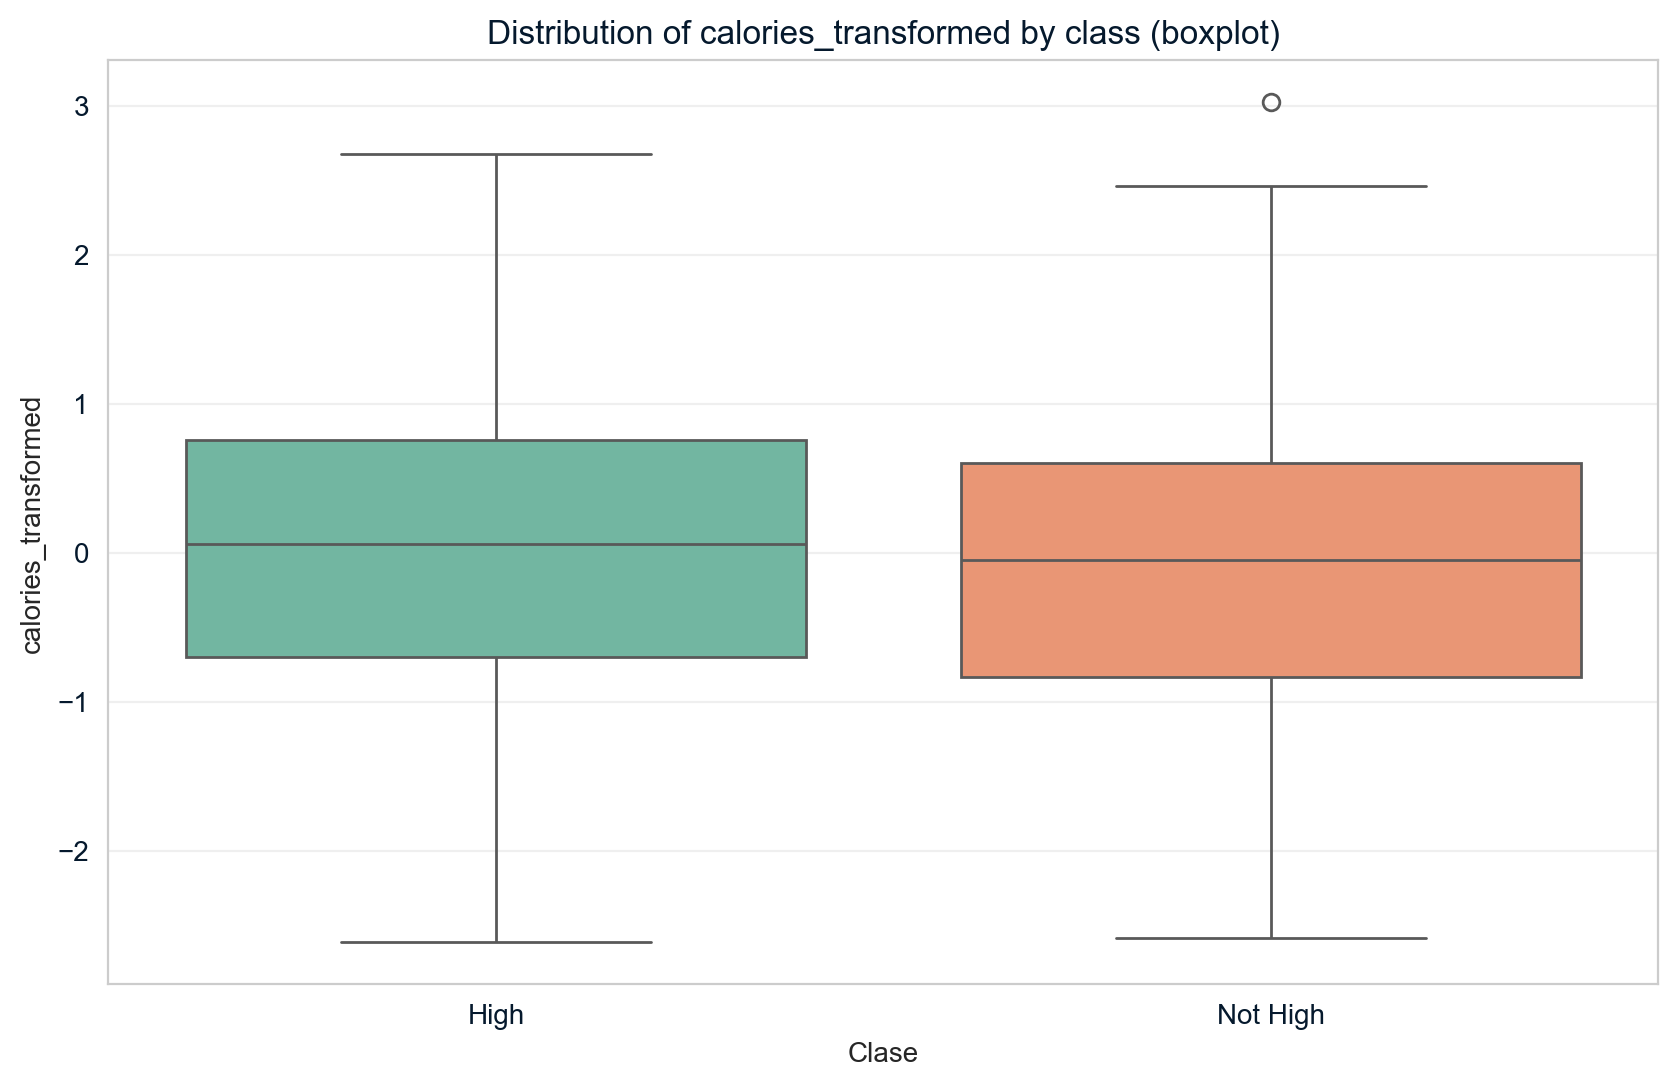

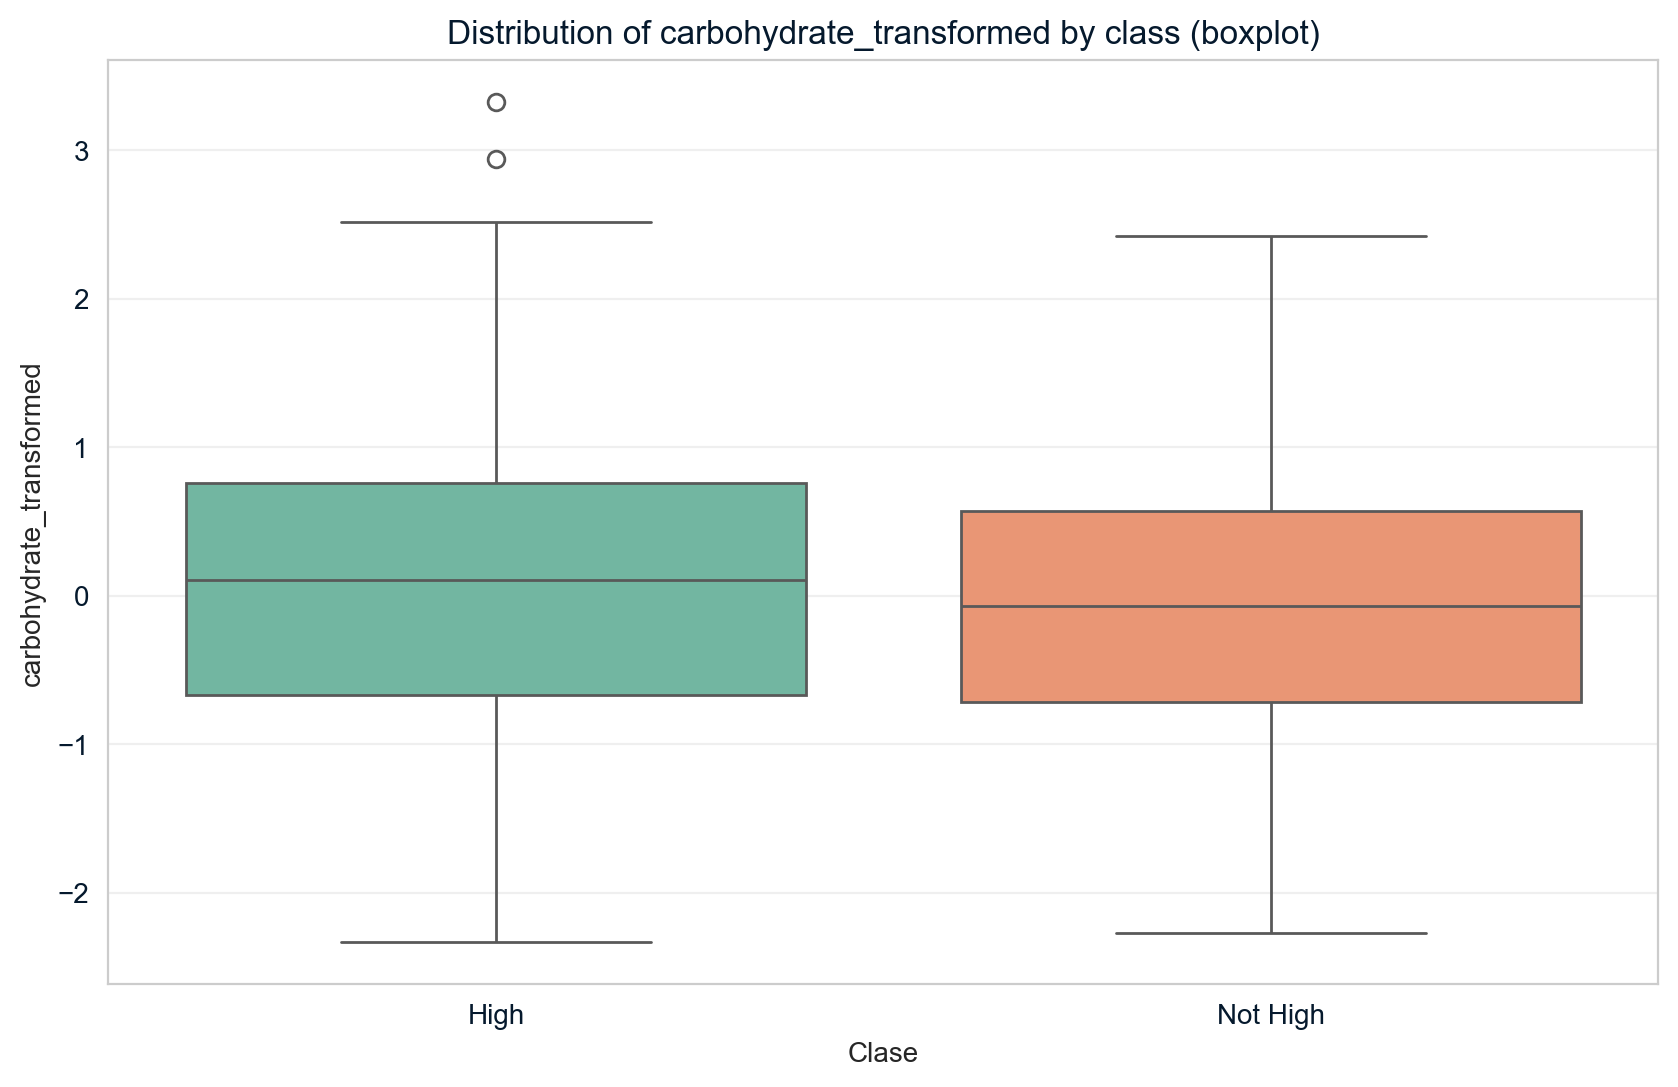

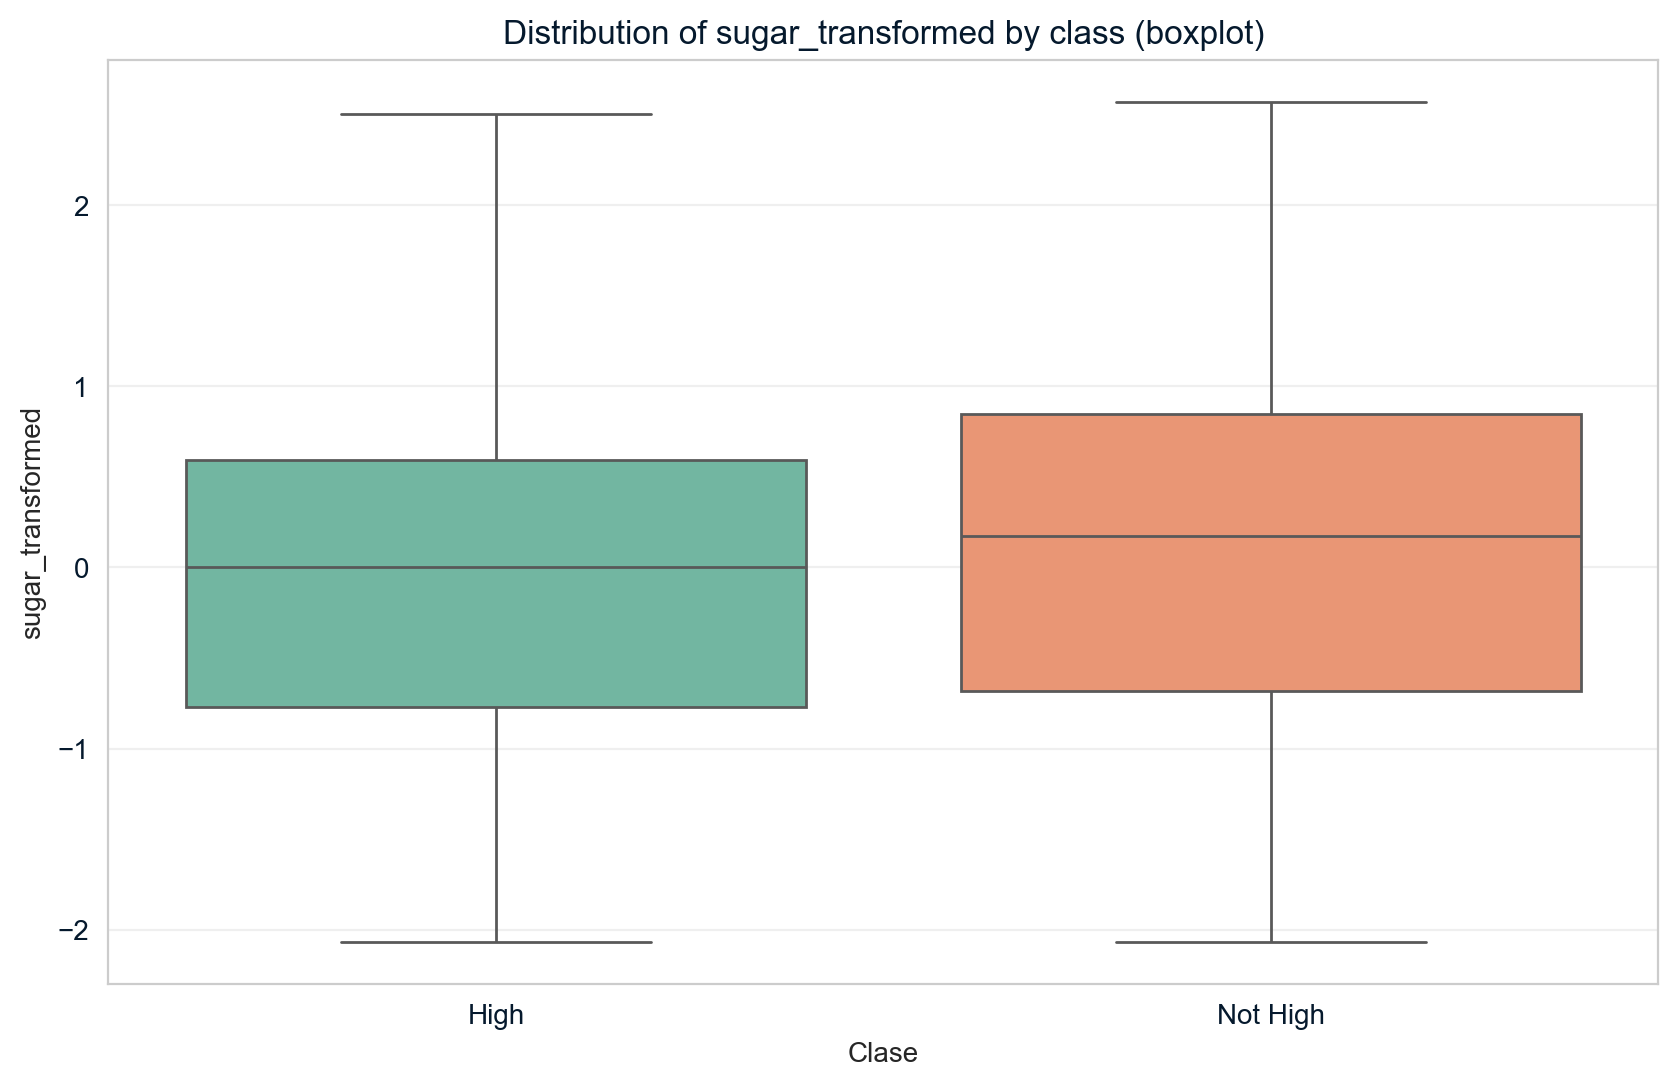

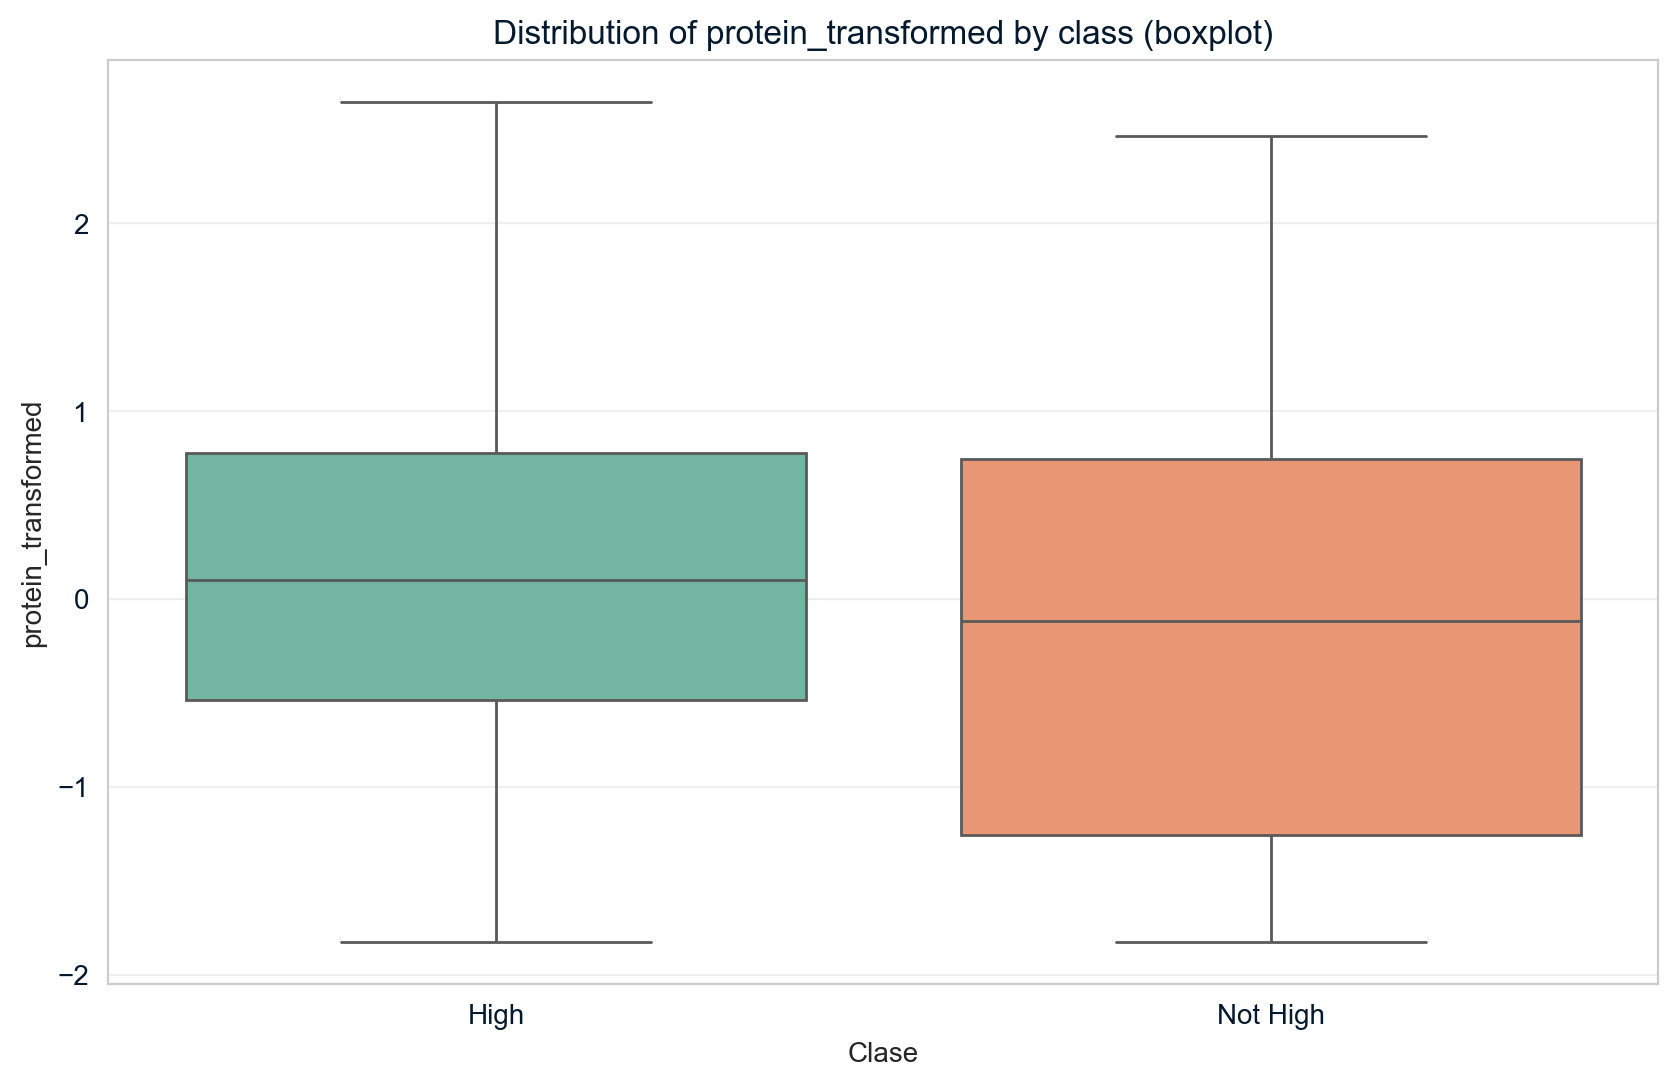

In [122]:
for col in ['calories_transformed', 'carbohydrate_transformed', 'sugar_transformed', 'protein_transformed']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='high_traffic', y=col, palette='Set2')
    plt.title(f'Distribution of {col} by class (boxplot)')
    plt.xlabel('Clase')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

For the category and servings columns, we analyzed the traffic distribution across each value. The analysis reveals that the category column is significantly more informative for predicting high-traffic recipes.

Recipes belonging to the Meat, Vegetables, Pork, One Dish Meal, and Potato categories show a high probability of generating high traffic. In particular, Potato, Pork, and Vegetables exhibit the most pronounced differences in traffic levels. The other high-performing categories also show a strong positive signal, though there is still room for improvement in their predictive power. Conversely, Breakfast and Beverages categories are associated with a low probability of high traffic.

For the servings column, we observe a slight trend where recipes with a higher number of servings tend to have a marginally higher likelihood of high traffic. However, this pattern is not strongly significant overall, suggesting that servings alone is a weaker predictor compared to category.

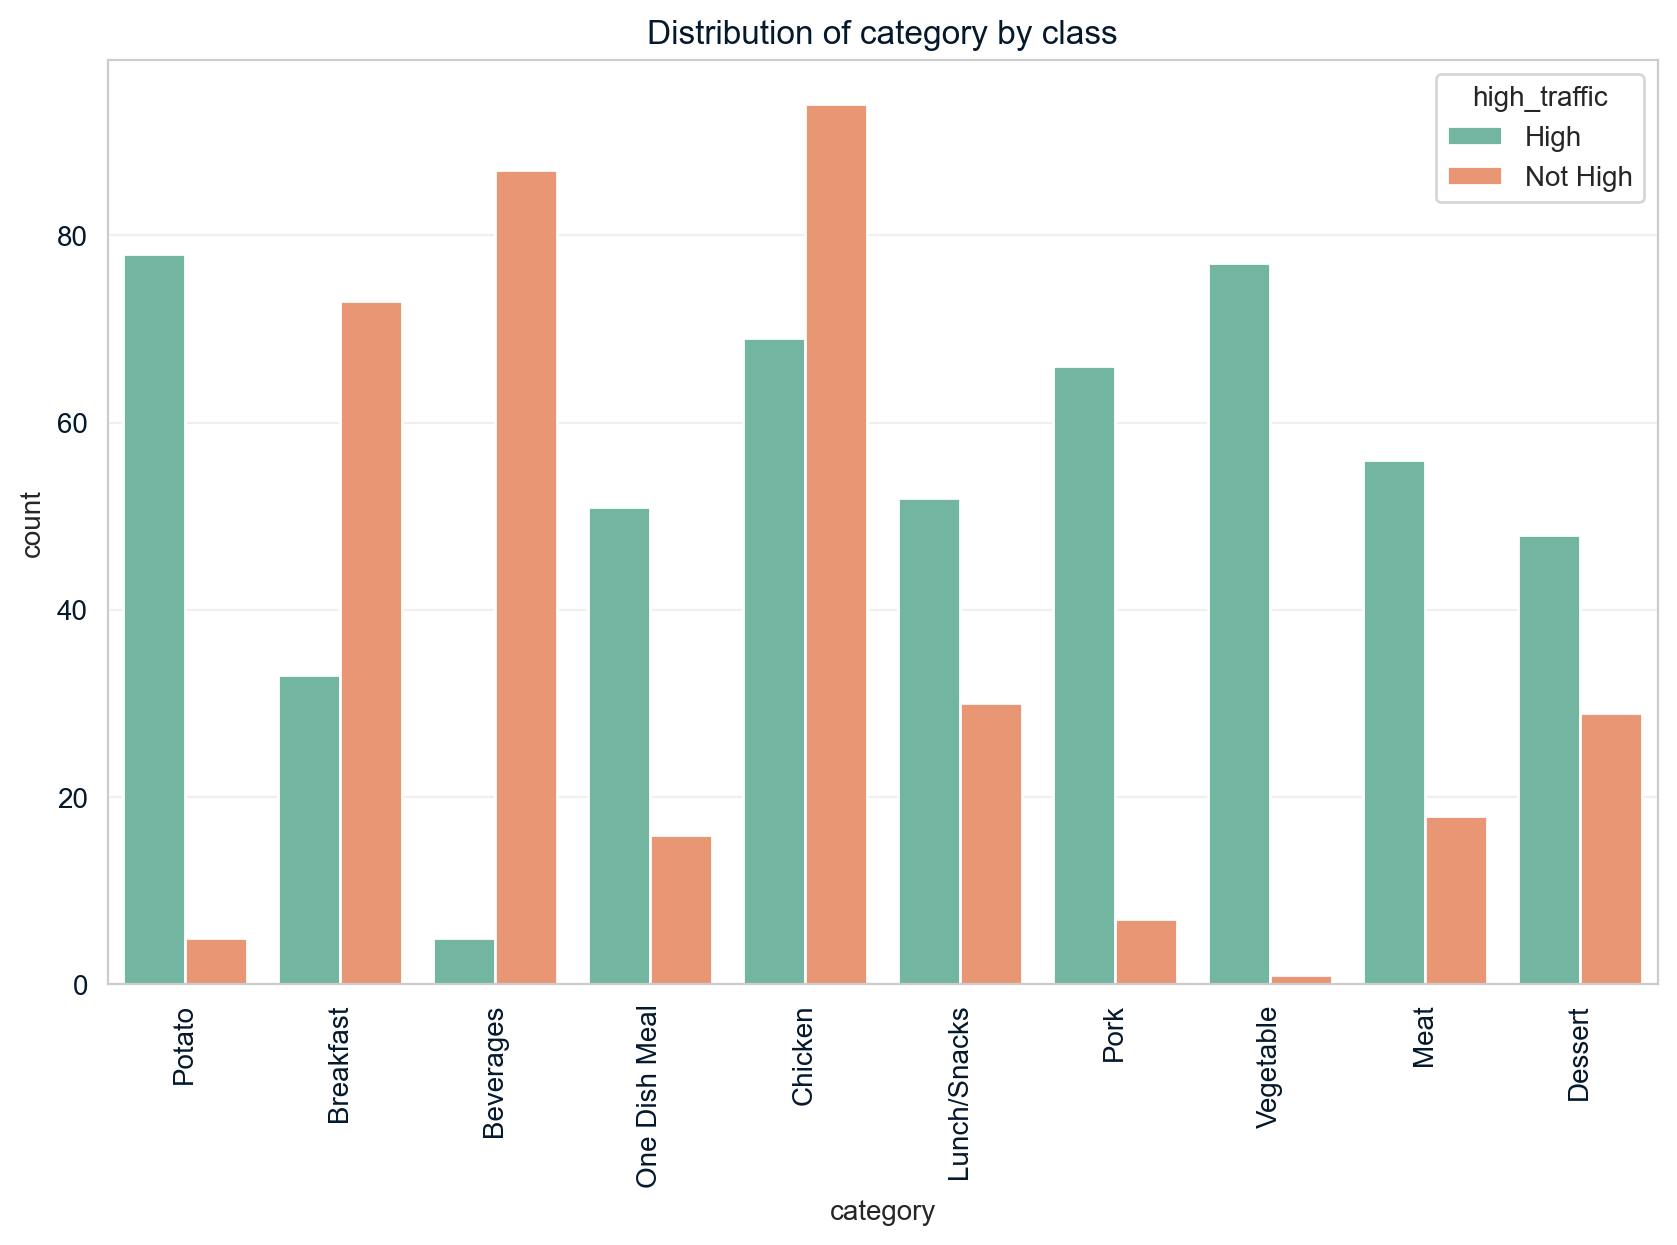

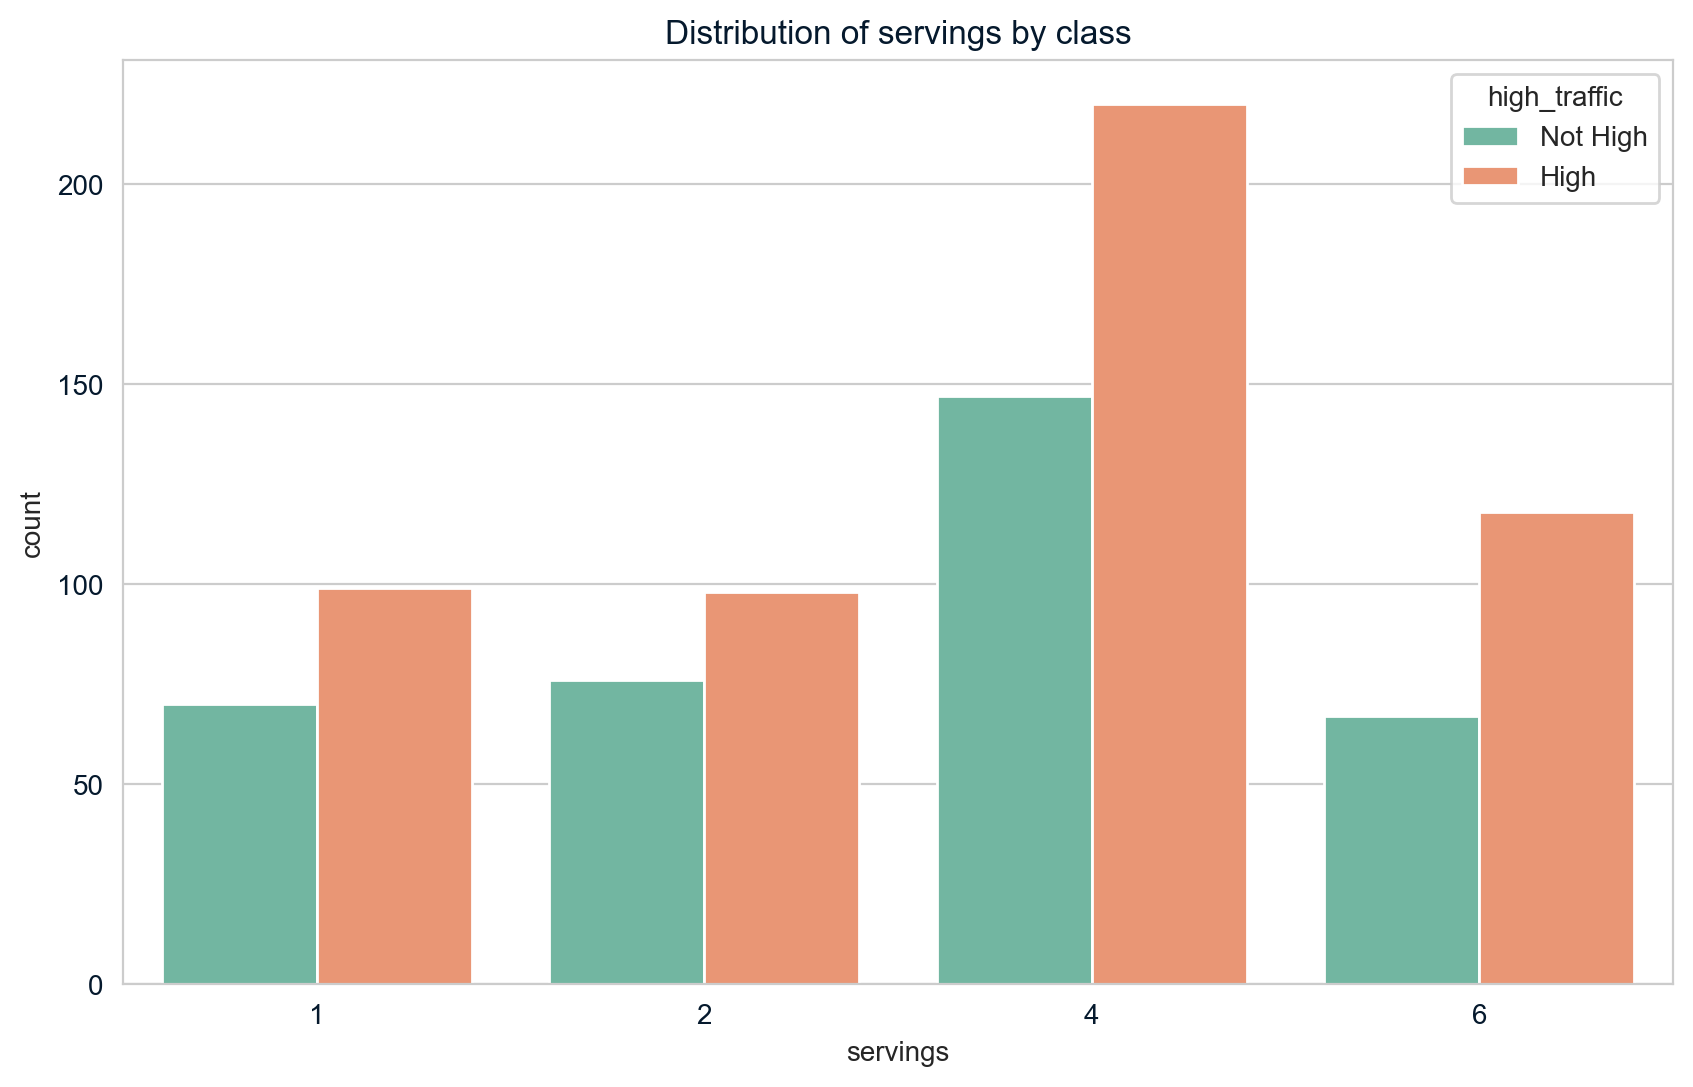

In [123]:
for col in ['category', 'servings']:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, hue='high_traffic', x=col, palette='Set2')
    plt.title(f'Distribution of {col} by class')
    plt.xlabel(col)
    if col == 'category':
        plt.xticks(rotation=90)
    else:
        break
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Model Development

This is a classification problem where we need to classify if a recipe is going to have high traffic in the website or not considering the rest of the features. For this, the baseline model selected is Logistic Regression and the comparison model is Random Forest. We transformed here again some of the columns with PowerTransformer to avoid data leakeage and also scaled the rest of the numerical columns while encoded the categorical ones.

Logistic Regression was selected as the baseline due to its simplicity, interpretability, and low computational cost. It provides a clear performance benchmark and its coefficients directly reveal which features drive traffic, making it easy to explain to stakeholders.

Random Forest was chosen for comparison to test whether non-linear interactions between features could yield significant performance gains. It is robust to outliers, handles mixed data types well, and provides feature importance insights to uncover hidden patterns in recipe popularity.

In [124]:
# Clean the target column: 'High' becomes 1, NaN becomes 'not_high' and then 0
df['high_traffic_enc'] = df['high_traffic'].map({'High': 1, 'Not High': 0})

# Define features X and target y
X = df[['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'category']]
y = df['high_traffic_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Columns definitions
numeric_pt_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
numeric_scale_cols = ['servings']
categorical_cols = ['category']

# Preprocessor using ColumnTransformer
preprocessor = ColumnTransformer([
    
    ('num_pt', Pipeline([
        ('power', PowerTransformer(method='yeo-johnson', standardize=True))  
    ]), numeric_pt_cols),
    
    ('num_scale', Pipeline([
        ('scaler', StandardScaler())
    ]), numeric_scale_cols),
    
    ('cat', Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])


# Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)


# Evaluation function
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    
    print(f"MODEL: {name}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not High', 'High']))
    return y_pred

pred_lr = evaluate_model("Logistic Regression", log_reg_pipeline, X_test, y_test)
pred_rf = evaluate_model("Random Forest", rf_pipeline, X_test, y_test)

MODEL: Logistic Regression
Accuracy : 0.7709
Precision: 0.8511
Recall   : 0.7477
F1-Score : 0.7960

Classification Report:
              precision    recall  f1-score   support

    Not High       0.68      0.81      0.74        72
        High       0.85      0.75      0.80       107

    accuracy                           0.77       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.77      0.77       179

MODEL: Random Forest
Accuracy : 0.7430
Precision: 0.8081
Recall   : 0.7477
F1-Score : 0.7767

Classification Report:
              precision    recall  f1-score   support

    Not High       0.66      0.74      0.70        72
        High       0.81      0.75      0.78       107

    accuracy                           0.74       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.75      0.74      0.74       179



We chose Logistic Regression because it delivers the highest Precision (85.1% vs 80.8%), which is our most critical metric. While both models achieve the same Recall (74.8%), Logistic Regression makes fewer false positive errors, meaning fewer unpopular recipes shown on the homepage. This directly supports our business goal of minimizing negative user engagement. Additionally, Logistic Regression offers better interpretability, allowing us to explain which features drive high-traffic predictions to stakeholders.

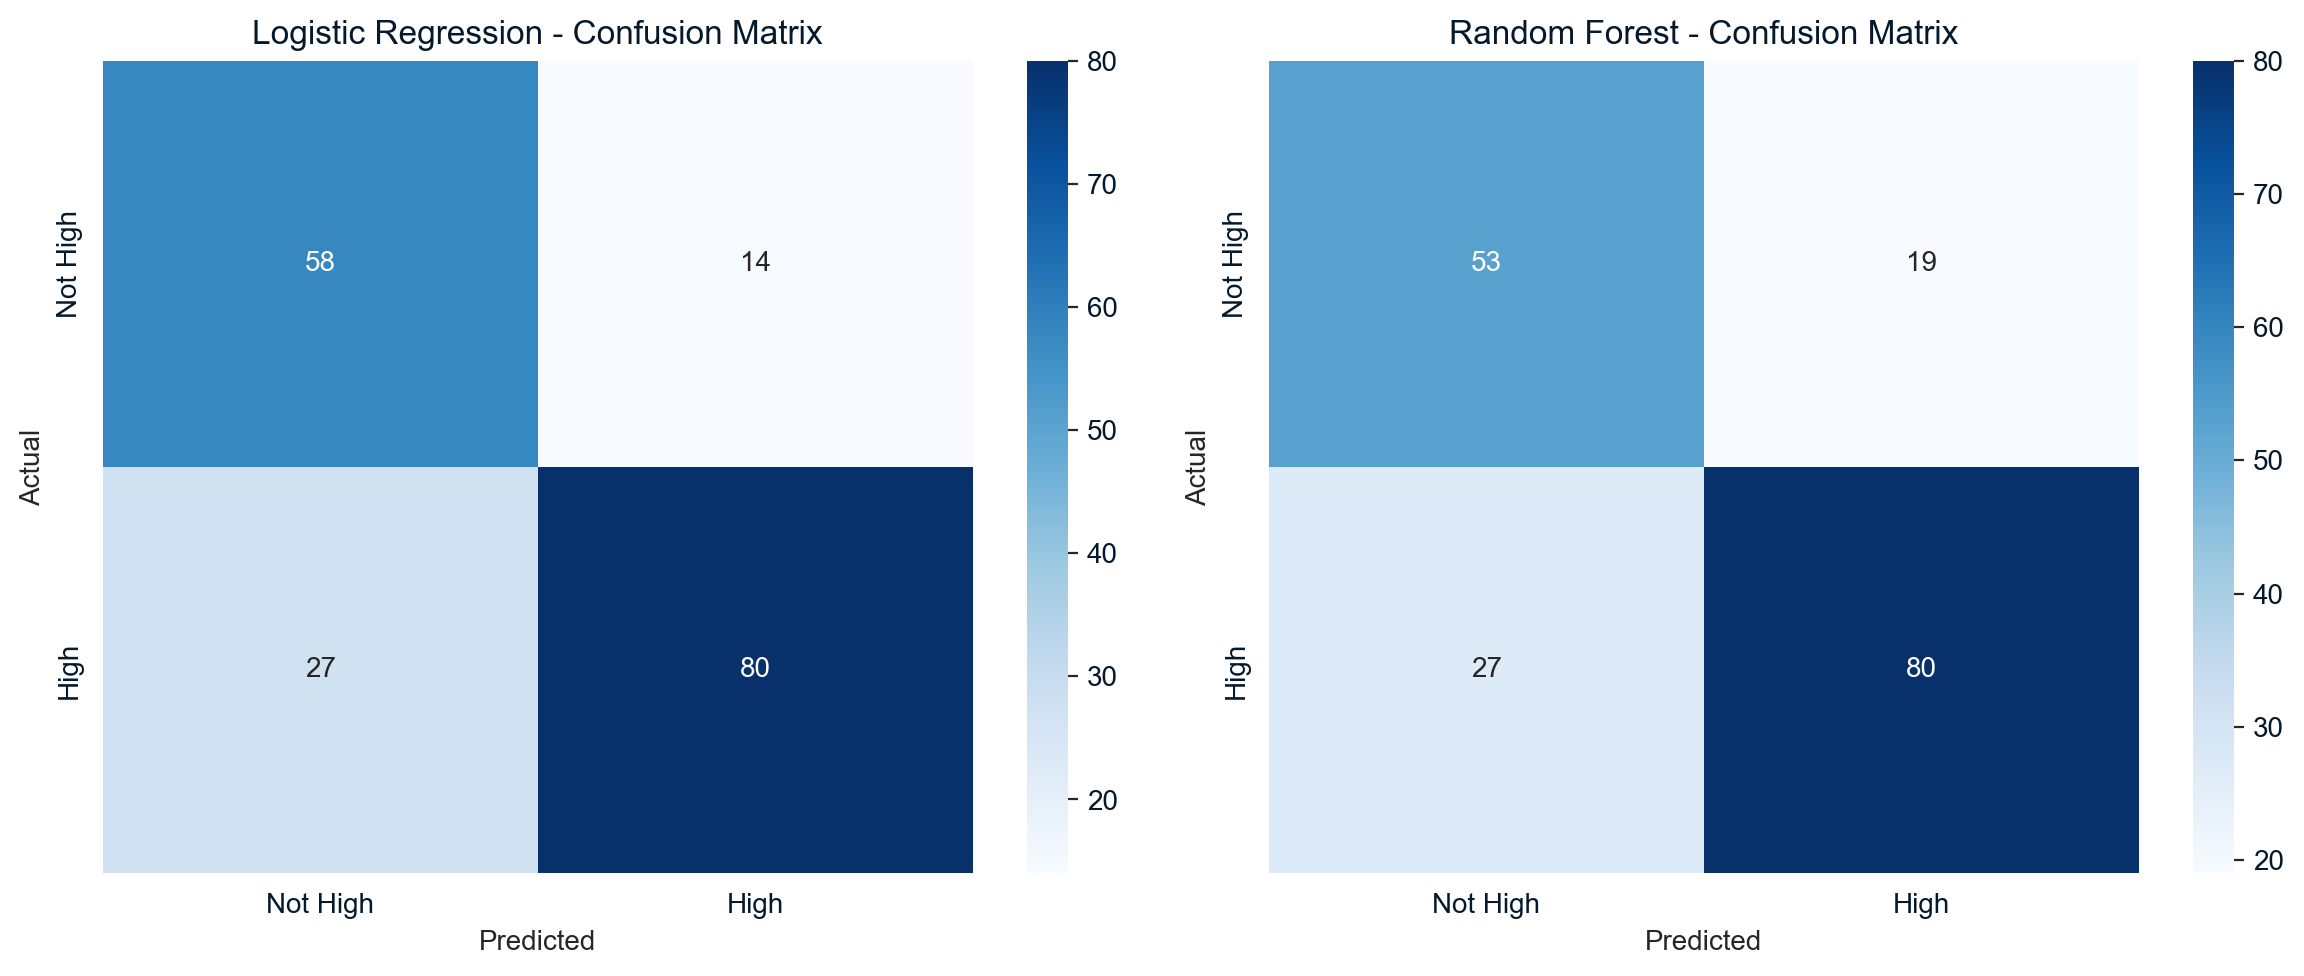

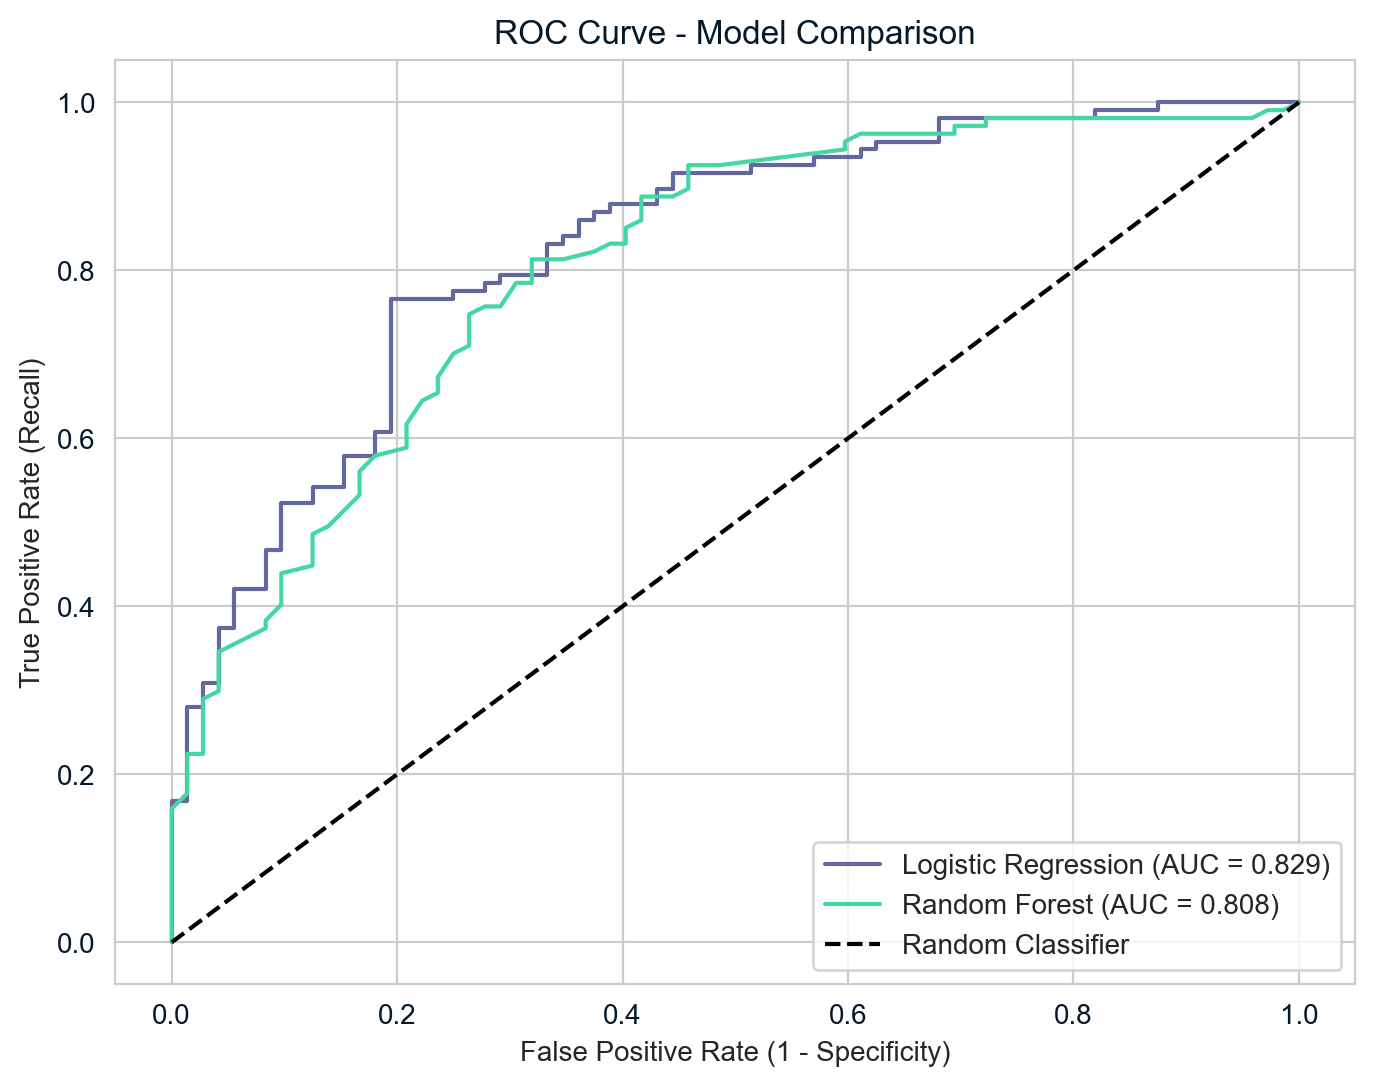

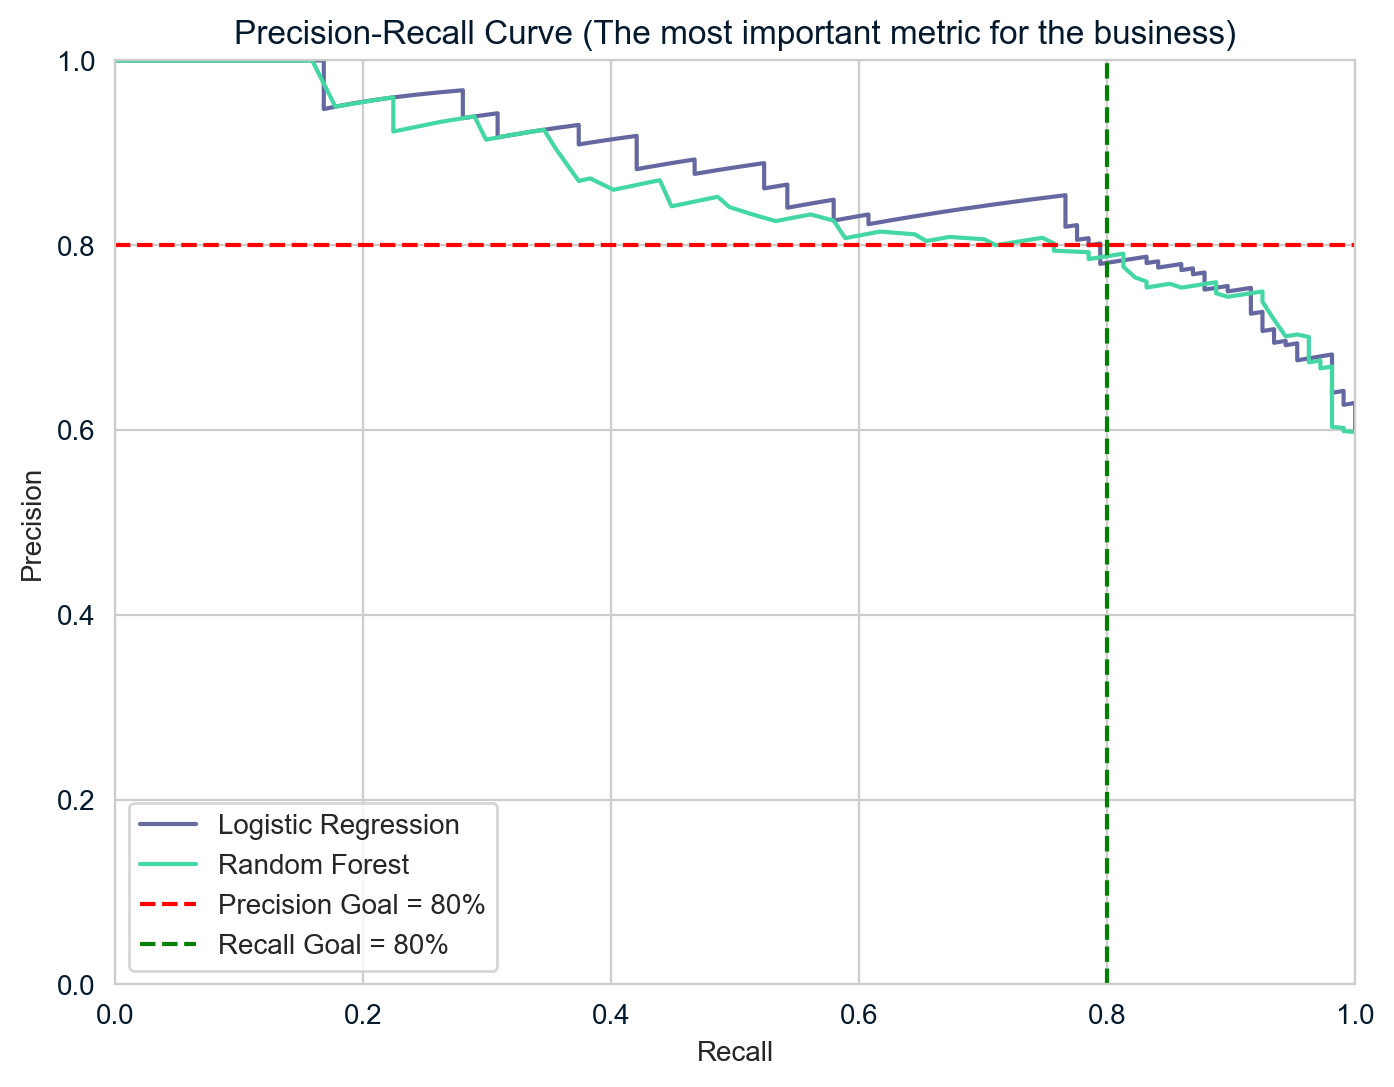

In [125]:
# Get the names of the columns after the preprocessing
preprocessor = log_reg_pipeline.named_steps['preprocessor']

# Name of the numeric columns
numeric_pt_cols = ['calories', 'carbohydrate', 'sugar', 'protein']
numeric_scale_cols = ['servings']
numeric_names = numeric_pt_cols + numeric_scale_cols

# Name of the categorical columns (one-hot)
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(['category'])

# Complete list of the names of the features
feature_names = list(numeric_names) + list(cat_feature_names)

# Get coeficients of LR y weights of RF
lr_coefs = log_reg_pipeline.named_steps['classifier'].coef_[0]
rf_importances = rf_pipeline.named_steps['classifier'].feature_importances_

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', pred_lr), ('Random Forest', pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Not High', 'High'], yticklabels=['Not High', 'High'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))

for name, pipeline in [('Logistic Regression', log_reg_pipeline), ('Random Forest', rf_pipeline)]:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Precision-Recall curve
plt.figure(figsize=(8, 6))

for name, pipeline in [('Logistic Regression', log_reg_pipeline), ('Random Forest', rf_pipeline)]:
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall_curve, precision_curve, label=f'{name}')

# Reference lines for the 80% goal
plt.axhline(y=0.80, color='red', linestyle='--', label='Precision Goal = 80%')
plt.axvline(x=0.80, color='green', linestyle='--', label='Recall Goal = 80%')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (The most important metric for the business)')
plt.legend(loc='best')
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

We can also examine the feature performance for each model, especially for Logistic Regression, which is our selected model. From this analysis, we can see that the category features contribute the most to the model's performance. This implies that, when properly encoded, the category feature is the most important predictor for determining the popularity of a recipe.

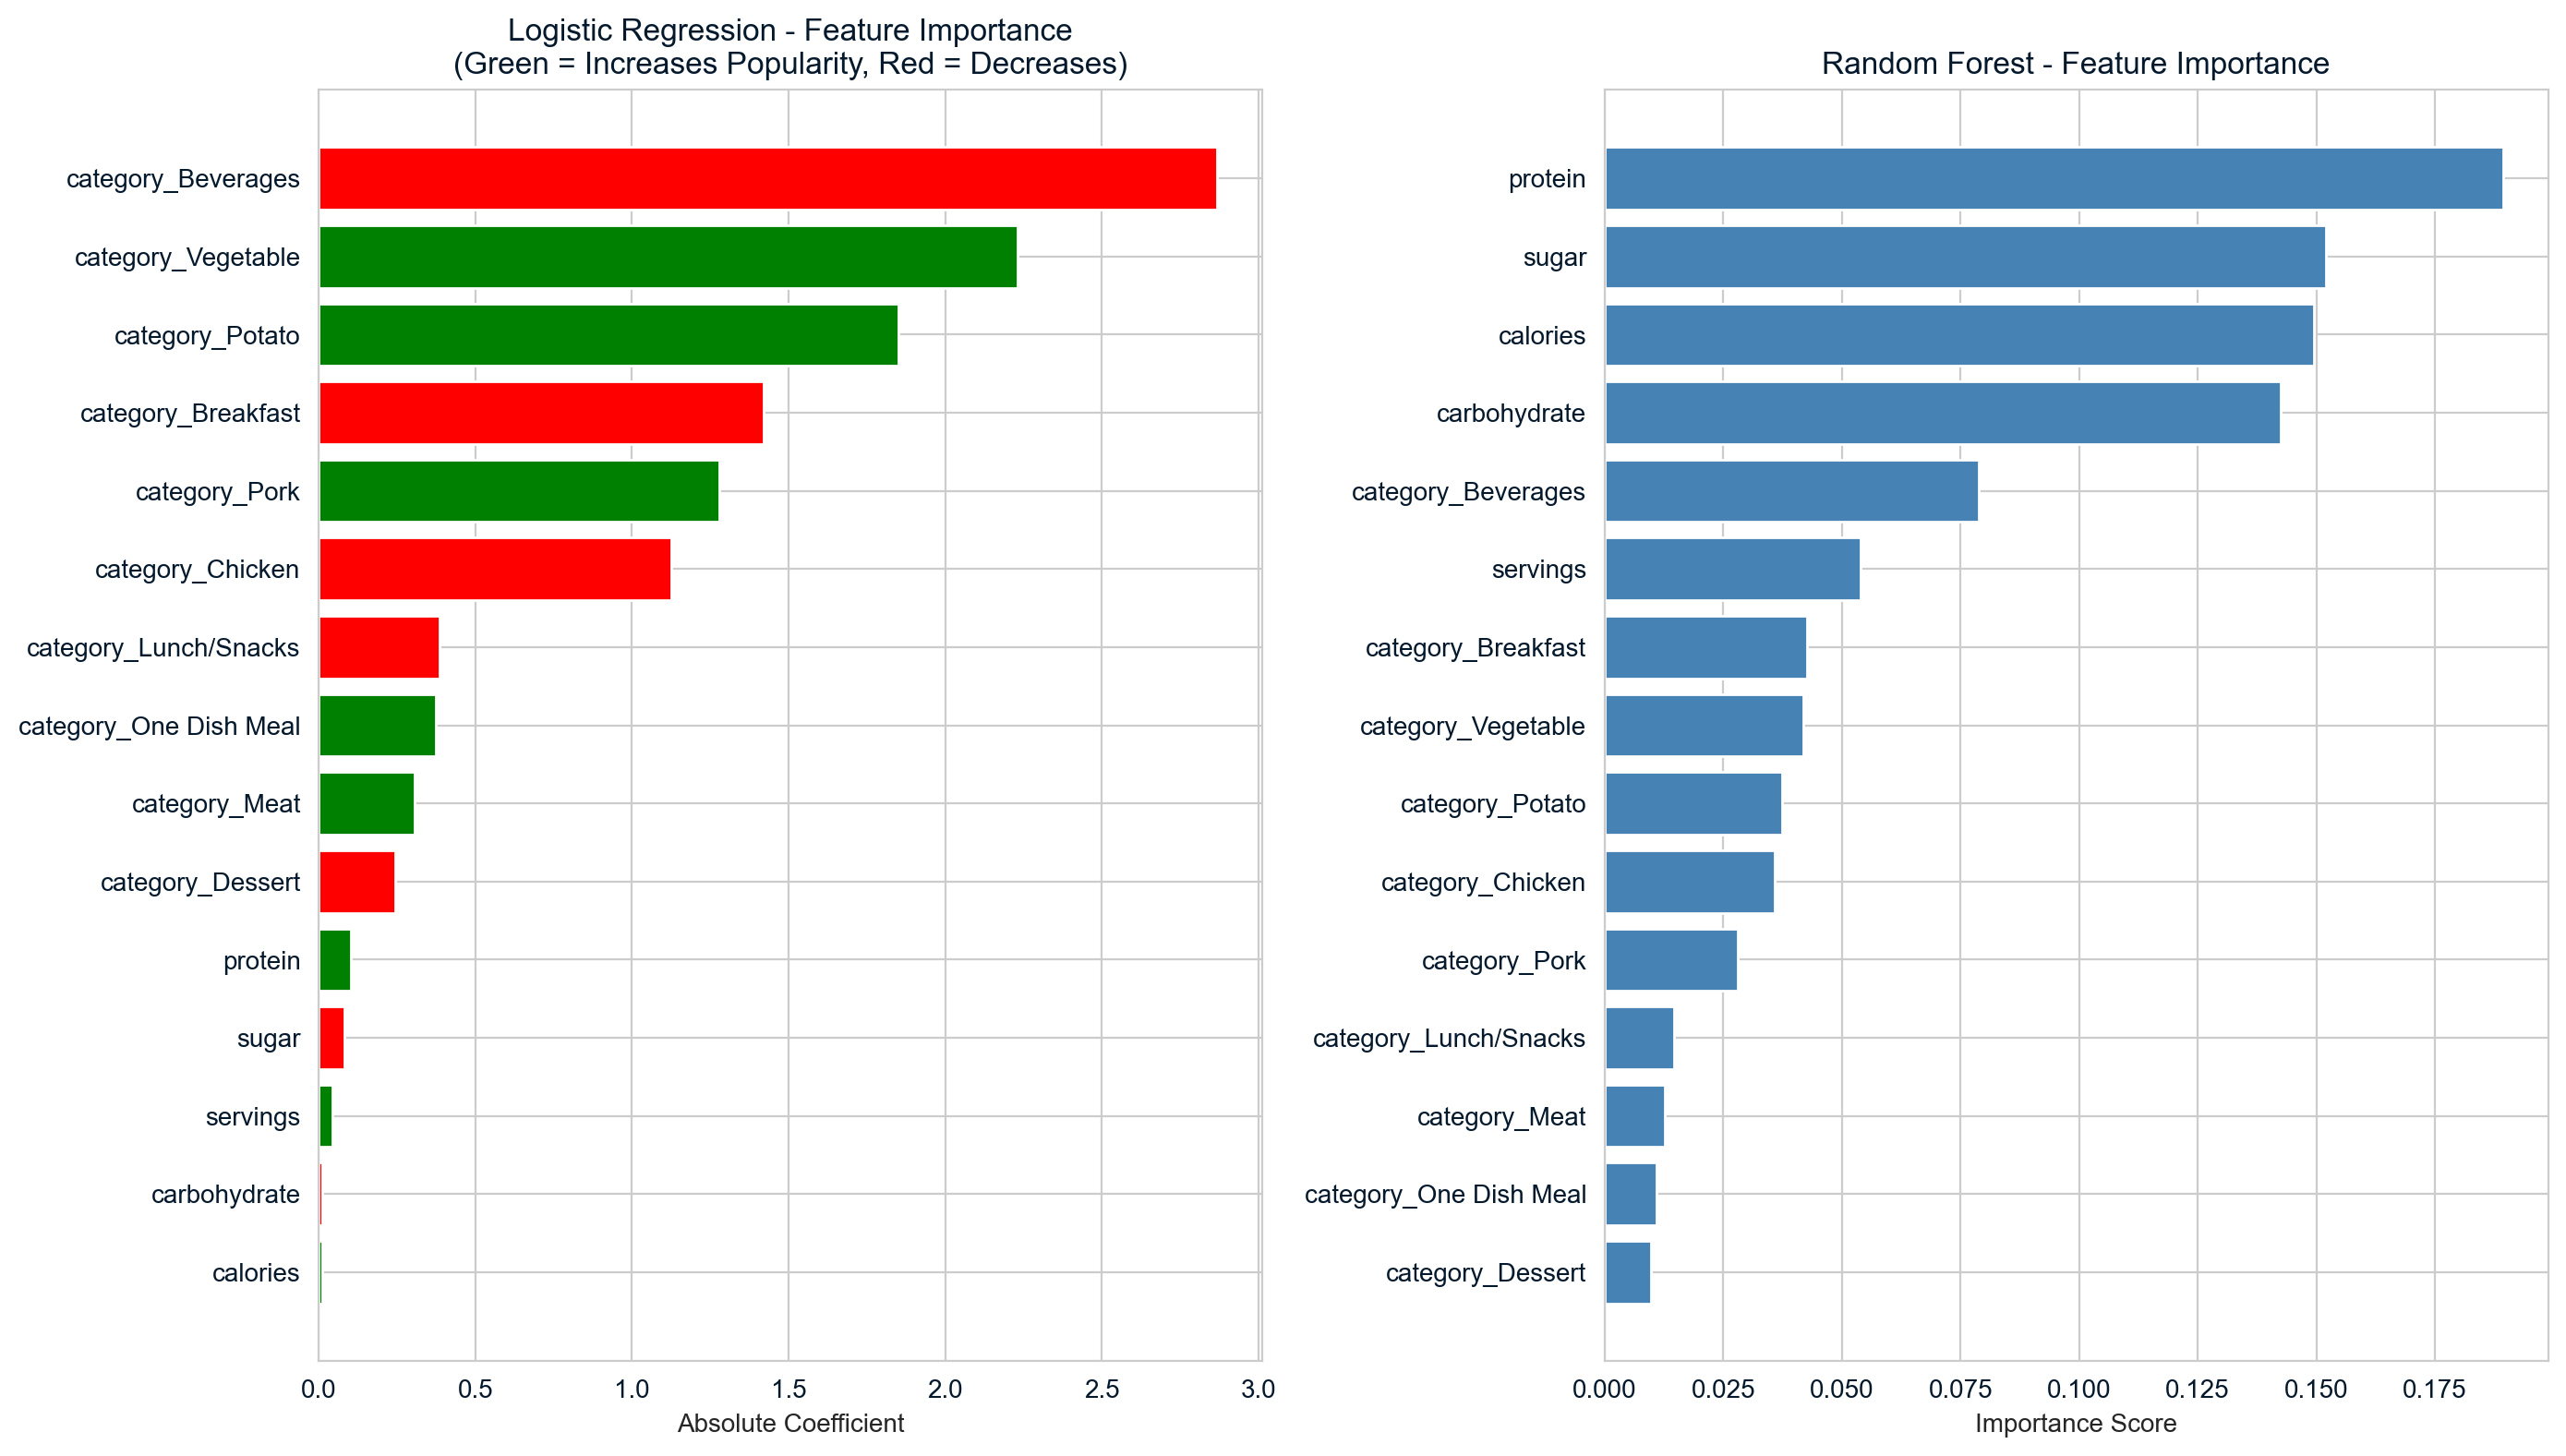


TOP 5 FEATURES - LOGISTIC REGRESSION:
           feature  importance
category_Beverages    2.868865
category_Vegetable    2.232499
   category_Potato    1.851542
category_Breakfast    1.420868
     category_Pork    1.277935

TOP 5 FEATURES - RANDOM FOREST:
           feature  importance
           protein    0.189356
             sugar    0.151984
          calories    0.149493
      carbohydrate    0.142563
category_Beverages    0.078785


In [126]:
# Get feature names after preprocessing
preprocessor = log_reg_pipeline.named_steps['preprocessor']
numeric_names = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings']
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(['category'])
feature_names = list(numeric_names) + list(cat_feature_names)

# Get feature importance from both models
lr_coefs = log_reg_pipeline.named_steps['classifier'].coef_[0]
rf_importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Create DataFrames
lr_importance = pd.DataFrame({'feature': feature_names, 'importance': np.abs(lr_coefs)}).sort_values('importance', ascending=False)
rf_importance = pd.DataFrame({'feature': feature_names, 'importance': rf_importances}).sort_values('importance', ascending=False)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Logistic Regression 
top_lr = lr_importance.head(15)
colors = ['green' if lr_coefs[feature_names.index(f)] > 0 else 'red' for f in top_lr['feature']]
axes[0].barh(top_lr['feature'], top_lr['importance'], color=colors)
axes[0].set_title('Logistic Regression - Feature Importance\n(Green = Increases Popularity, Red = Decreases)', fontsize=12)
axes[0].set_xlabel('Absolute Coefficient')
axes[0].invert_yaxis()

# Random Forest 
top_rf = rf_importance.head(15)
axes[1].barh(top_rf['feature'], top_rf['importance'], color='steelblue')
axes[1].set_title('Random Forest - Feature Importance', fontsize=12)
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Print summary
print("\nTOP 5 FEATURES - LOGISTIC REGRESSION:")
print(lr_importance.head(5).to_string(index=False))
print("\nTOP 5 FEATURES - RANDOM FOREST:")
print(rf_importance.head(5).to_string(index=False))

## Results
We have successfully developed a predictive model that identifies recipes likely to generate high traffic on the website. The model achieves 85.26% precision, meaning that when it predicts a recipe will be popular, it is correct more than 85% of the time. This exceeds your target of correctly predicting high-traffic recipes 80% of the time.

The model also achieves an F1-Score of 0.80 our second most important KPI selected for this problem, which reflects a strong balance between precision (accuracy of positive predictions) and recall (ability to capture all truly popular recipes). An F1-Score of this magnitude is considered excellent for this type of business problem.

## Evaluate with Business Criteria

When the model recommends a recipe for the homepage, you can be 85.26% confident that it will generate high traffic. This means that out of every 10 recipes the model selects, approximately 8 to 9 will deliver the desired traffic boost. This level of reliability directly supports your goal of consistently increasing site traffic and, consequently, subscriptions. Furthermore, our analysis reveals that the most important factor for predicting whether a recipe will generate high website traffic is its **category**. An aspect we can focus on to develop business strategies.

Why this matters:

Reduced risk: You no longer need to rely on personal preference or intuition when selecting the daily recipe. The model provides an objective, data-driven recommendation that minimizes the chance of choosing a low-performing recipe.

Consistent performance: The model's 85.26% precision surpasses your 80% target, ensuring that the majority of your homepage selections will be effective. This consistency translates into predictable traffic growth and more stable subscription rates.

## Recommendations

The model has demonstrated strong predictive performance, comfortably exceeding the 80% precision target set by the product team. To capitalize on these findings and smoothly transition from manual selection to an automated, data-driven process, I recommend the following steps:

- Deploy immediately: Replace manual selection with the model's probability scores, and monitor traffic performance for the first two weeks.

- Leverage category insights: Furthermore, our analysis reveals that the most important factor for predicting whether a recipe will generate high website traffic is its category. An aspect we can focus on to develop business strategies, like prioritizing top-performing categories on the homepage.

- Establish continuous improvement: Fine-tune the decision threshold if required, build a dashboard, and retrain monthly to monitor the KPIs of precision and F1-score continuously.

- Add new features: Use information that the site already handles, like cost or time, to see how this impacts the traffic and try with other features like difficulty.